<a href="https://colab.research.google.com/github/mairafaq08/assessment/blob/main/Assesment_File.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn import preprocessing
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [59]:
! git config --global user.name "mairafaq08" # replace with your username that you used to create the Github account
! git config --global user.email "afaqmaira05@gmail.com" # and the email id which you have used to create account

In [62]:
username = "mairafaq08" #replace with your own user name
repo = "assessment" #replace with your required repo

In [63]:
! git clone https://@github.com/{username}/{repo}



Cloning into 'assessment'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 13 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 4.99 MiB | 6.52 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [64]:
%cd {repo}
%ls

/content/assessment/assessment
Assesment_File.ipynb
PRSA_Data_Dingling_20130301-20170228.csv
PRSA_Data_Dongsi_20130301-20170228.csv
PRSA_Data_Huairou_20130301-20170228.csv
PRSA_Data_Wanshouxigong_20130301-20170228.csv


# **Task-1: Data Selection & Handling**

In [68]:
# Defining datasets based on regions/sites
urban_files = ['PRSA_Data_Dongsi_20130301-20170228.csv', 'PRSA_Data_Wanshouxigong_20130301-20170228.csv']
suburban_files = ['PRSA_Data_Dingling_20130301-20170228.csv', 'PRSA_Data_Huairou_20130301-20170228.csv']

def load_and_tag(files, region_name):
    dataframes = []
    for f in files:
        temp_df = pd.read_csv(f)
        temp_df['region'] = region_name
        dataframes.append(temp_df)
    return pd.concat(dataframes)

# Combine all into one master dataframe
df_urban = load_and_tag(urban_files, 'Urban')
df_suburban = load_and_tag(suburban_files, 'Sub-urban')
full_df = pd.concat([df_urban, df_suburban])

# Create a proper datetime object
full_df['datetime'] = pd.to_datetime(full_df[['year', 'month', 'day', 'hour']])

print("Data loaded and categorized by region.")
display(full_df.groupby('region').size())
full_df

Data loaded and categorized by region.


,0
region,
Sub-urban,70128
Urban,70128


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,region,datetime
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi,Urban,2013-03-01 00:00:00
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi,Urban,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi,Urban,2013-03-01 02:00:00
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi,Urban,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi,Urban,2013-03-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou,Sub-urban,2017-02-28 19:00:00
35060,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou,Sub-urban,2017-02-28 20:00:00
35061,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou,Sub-urban,2017-02-28 21:00:00
35062,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou,Sub-urban,2017-02-28 22:00:00


# **Task-2: Exploratory Data Analysis**

# 2.1. Data Understanding

 Provide an overview that may include the following, but not limited to:

* Number of rows and columns
* Column descriptions
* Data types
* Missing values
* Statistical Summary
* Initial observations & interpretation

In [69]:
# No of Columns and Rows
#full_df.shape
rows, columns = full_df.shape
print(f"Rows: {rows}, Columns: {columns}")

# Columns List
full_df.columns

Rows: 140256, Columns: 20


Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station',
       'region', 'datetime'],
      dtype='object')

In [70]:
## Data Types & Column description ##
#full_df.info()
# ─── Column Descriptions ───────────────────────────────────────────
COL_DESC = {
    "No"          : "Original row index",
    "year"        : "Year of measurement",
    "month"       : "Month of measurement (1–12)",
    "day"         : "Day of month",
    "hour"        : "Hour of day (0–23)",
    "PM2.5"       : "Fine particulates <2.5 μm  (μg/m³)",
    "PM10"        : "Coarse particulates <10 μm  (μg/m³)",
    "SO2"         : "Sulfur dioxide concentration (μg/m³)",
    "NO2"         : "Nitrogen dioxide concentration (μg/m³)",
    "CO"          : "Carbon monoxide concentration (μg/m³)",
    "O3"          : "Ozone concentration (μg/m³)",
    "TEMP"        : "Ambient temperature (°C)",
    "PRES"        : "Atmospheric pressure (hPa)",
    "DEWP"        : "Dew point temperature (°C)",
    "RAIN"        : "Precipitation (mm)",
    "wd"          : "Wind direction (compass direction, categorical)",
    "WSPM"        : "Wind speed (m/s)",
    "station"     : "Monitoring station name",
    "datetime"    : "Timestamp (date + hour, derived)",
    "region"      : "Urban or Suburban classification (derived)",
}
print(f"{'Column':<15}  {'Description'}")
print("-" * 70)
for col in full_df.columns:
    print(f"  {col:<15}  {COL_DESC.get(col, 'N/A')}")


Column           Description
----------------------------------------------------------------------
  No               Original row index
  year             Year of measurement
  month            Month of measurement (1–12)
  day              Day of month
  hour             Hour of day (0–23)
  PM2.5            Fine particulates <2.5 μm  (μg/m³)
  PM10             Coarse particulates <10 μm  (μg/m³)
  SO2              Sulfur dioxide concentration (μg/m³)
  NO2              Nitrogen dioxide concentration (μg/m³)
  CO               Carbon monoxide concentration (μg/m³)
  O3               Ozone concentration (μg/m³)
  TEMP             Ambient temperature (°C)
  PRES             Atmospheric pressure (hPa)
  DEWP             Dew point temperature (°C)
  RAIN             Precipitation (mm)
  wd               Wind direction (compass direction, categorical)
  WSPM             Wind speed (m/s)
  station          Monitoring station name
  region           Urban or Suburban classification (derive

In [71]:
stations = full_df['station'].value_counts()
print(f'Total number of Stations in the dataset : {len(stations)}')
stations

Total number of Stations in the dataset : 4


,count
station,
Dongsi,35064
Wanshouxigong,35064
Dingling,35064
Huairou,35064


In [72]:
## ----------------- Statistical Summary of Data set ------------------##
##full_df.head()
#full_df['year'].unique() ## all months

## yearly data based on months
full_df.groupby(['year', 'month','station'], as_index=True).first(2)
## some of the months are missing in some years

# ─── Statistical Summary ───────────────────────────────────────────
NUM_COLS = ["PM2.5","PM10","SO2","NO2","CO","O3","TEMP","PRES","DEWP","RAIN","WSPM"]
NUM_COLS = [c for c in NUM_COLS if c in full_df.columns]

summary = full_df[NUM_COLS].describe().T
summary["skewness"] = full_df[NUM_COLS].skew().round(2)
summary["kurtosis"] = full_df[NUM_COLS].kurt().round(2)
print("Statistical Summary of Numerical Variables:")
print(summary.round(2).to_string())


Statistical Summary of Numerical Variables:
          count     mean      std     min     25%     50%      75%      max  skewness  kurtosis
PM2.5  137078.0    76.72    79.87    2.00    18.0    52.0   107.00    999.0      2.06      6.29
PM10   137786.0    99.48    90.89    2.00    32.0    76.0   139.00    993.0      1.98      6.79
SO2    137214.0    14.90    20.81    0.29     2.0     7.0    18.00    411.0      3.09     14.55
NO2    135028.0    42.37    33.38    1.03    16.0    34.0    61.00    258.0      1.21      1.59
CO     132328.0  1155.98  1082.57  100.00   500.0   800.0  1500.00  10000.0      2.64     10.49
O3     136149.0    60.44    56.12    0.21    16.0    50.0    85.00   1071.0      2.04     14.40
TEMP   140113.0    13.40    11.50  -19.90     3.0    14.4    23.18     41.4     -0.12     -1.13
PRES   140114.0  1009.86    10.51  982.40  1001.3  1009.4  1018.00   1042.0      0.12     -0.81
DEWP   140111.0     2.22    13.85  -43.40    -9.3     2.7    14.90     29.1     -0.17     -1

In [73]:
####  ----------------  checking Missing values ------------------------------- ##

def missing_values_table(full_df):
    # Total missing values
    mis_val = full_df.isnull().sum()

    # Percentage of missing values
    mis_val_percent = 100 * mis_val / len(full_df)

    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

    mis_val_table = mis_val_table.rename(columns={0: 'Missing Values', 1: '% of Total Values'})

    # Sort the table by percentage of missing descending
    mis_val_table = mis_val_table.sort_values('% of Total Values', ascending=False)

    return mis_val_table

missing_values = missing_values_table(full_df)
display(missing_values.style.background_gradient(cmap='Blues'))

## CO has most missing values

,Missing Values,% of Total Values
CO,7928,5.652521
NO2,5228,3.727470
O3,4107,2.928217
PM2.5,3178,2.265857
SO2,3042,2.168891
PM10,2470,1.761065
wd,599,0.427076
DEWP,145,0.103382
RAIN,145,0.103382
TEMP,143,0.101956


**KEY** INITIAL OBSERVATIONS
═══════════════════════════════════════════════════════════
1. PM2.5 RANGE    : Min ≈ 0  Max ≈ 950 μg/m³ — extreme outliers present.
                    Mean ~72 μg/m³ far exceeds WHO guideline of 15 μg/m³.

2. SKEWNESS       : PM2.5, CO, SO2, NO2 are highly right-skewed (>3),
                    indicating frequent low values with rare extreme spikes.

3. MISSING DATA   : ~5–6% missing across pollutant columns;
                    RAIN has the highest missingness (likely zero-inflated).
                    Meteorological vars are nearly complete.

4. CO SCALE       : CO values in μg/m³ are orders of magnitude larger
                    than other gases — requires scaling for ML.

5. TEMPORAL SPAN  : 4 years × 4 stations = ~140,000 hourly records,
                    providing strong temporal coverage for trend analysis.

6. WIND DIRECTION : 'wd' column is categorical — requires encoding for ML.
7. Year , Month , Day , hour columns are already given. No need to extract them from datetime column.
8. AQI data is not available. Need to calculate and create new AQI column as per given pollutants
10. No duplicates found
11. some of the months are missing from some of the years. Seasonal analysis can be done only on the year basis which has 12 months
12. meteorological data is given such as 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM' for meteorological analysis

# 2.2. Data Processing

In [74]:
#### ---------- checking duplicates --------------## Not found
full_df['station'].unique()
print(f"There are  {full_df.duplicated().sum()} duplicates in the dataset")

There are  0 duplicates in the dataset


In [76]:
# Make a copy of original data BEFORE any cleaning
df_raw = full_df.copy()

In [78]:
## ---------------- Dropping useless column -----------------##
#full_df = full_df.drop(['No','wd'], axis=1)
full_df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,region,datetime
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi,Urban,2013-03-01 00:00:00
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi,Urban,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi,Urban,2013-03-01 02:00:00
3,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi,Urban,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi,Urban,2013-03-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou,Sub-urban,2017-02-28 19:00:00
35060,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou,Sub-urban,2017-02-28 20:00:00
35061,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou,Sub-urban,2017-02-28 21:00:00
35062,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou,Sub-urban,2017-02-28 22:00:00


In [79]:
## Replacing missing values

# PM10 and NH3 are seasonal and city-specific
# So we use median grouped by City + Month as the primary fill
# We add fallbacks for cities where entire months or entire series are missing

# ------------------------------------------------------------------
# LAMBDA EXPLANATION:
# lambda x: x.fillna(x.median())
#
# lambda = a small unnamed function, same as writing:
#   def fill_with_median(x):
#       return x.fillna(x.median())
#
# Here x is one group (e.g. all PM10 rows for Delhi in January)
# x.median() = median value of that group
# x.fillna(...) = fill NaN values with that median
# transform() applies this function to each group and returns
# result in the same shape as the original dataframe
# ------------------------------------------------------------------
# List of all pollutant columns you want to impute
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

for col in pollutants:
    # Fill missing values with the mean of the same station and month
    full_df[col] = full_df.groupby(['station', 'month'])[col].transform(lambda x: x.fillna(x.mean()))

print("PM10 nulls:", full_df['PM10'].isna().sum())
print("PM2.5 nulls:", full_df['PM2.5'].isna().sum())
print("SO2 nulls:", full_df['SO2'].isna().sum())
print("NO2 nulls:", full_df['NO2'].isna().sum())
print("CO nulls:", full_df['CO'].isna().sum())
print("O3 nulls:", full_df['O3'].isna().sum())



PM10 nulls: 0
PM2.5 nulls: 0
SO2 nulls: 0
NO2 nulls: 0
CO nulls: 0
O3 nulls: 0


In [80]:
#checking Missing values again
def missing_values_table(full_df):
    # Total missing values
    mis_val = full_df.isnull().sum()

    # Percentage of missing values
    mis_val_percent = 100 * mis_val / len(full_df)

    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

    mis_val_table = mis_val_table.rename(columns={0: 'Missing Values', 1: '% of Total Values'})

    # Sort the table by percentage of missing descending
    mis_val_table = mis_val_table.sort_values('% of Total Values', ascending=False)

    return mis_val_table

missing_values = missing_values_table(full_df)
display(missing_values.style.background_gradient(cmap='Blues'))



,Missing Values,% of Total Values
wd,599,0.427076
DEWP,145,0.103382
RAIN,145,0.103382
TEMP,143,0.101956
PRES,142,0.101243
WSPM,119,0.084845
year,0,0.000000
No,0,0.000000
day,0,0.000000
month,0,0.000000


In [81]:
## Missing values per station
missing_values_per_station = full_df.groupby('station').apply(lambda x: x.isnull().sum())
print("Total missing values per Station:")
print(full_df.groupby('station').apply(lambda x: x.isnull().sum().sum()))


Total missing values per Station:
station
Dingling         390
Dongsi           172
Huairou          563
Wanshouxigong    168
dtype: int64


# Feature Engineering

Calculating and creating new column for Air Quality Index with the given Air Pollutants like PM2.5 and PM10



Calculating Air Quality Index:

1. The Standard AQI Formula
For any individual pollutant, the index (
) is calculated as follows:

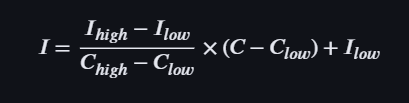

* C: The measured concentration of the pollutant (e.g., your
 value).

* C(low),C(high): The concentration breakpoints (lower and upper) that your value falls between.

* I(low) , I(high): The corresponding AQI breakpoints for those concentrations.


In [82]:
full_df.columns

Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station',
       'region', 'datetime'],
      dtype='object')

In [83]:
# Datetime components -- Calculating day in week and time of the day
# Note: Year, month ,day, Hour columns are already available in the dataset. No need to derive from datetime

## Day of the Week

full_df["day_of_week"] = full_df["datetime"].dt.dayofweek   # 0=Mon
full_df["day_name"]    = full_df["datetime"].dt.day_name()
full_df["is_weekend"]  = full_df["day_of_week"].isin([5, 6]).astype(int)
print("   ✅ Datetime components: hour, day, month, year, day_of_week, is_weekend")
#full_df.head()

# Time of day
def time_of_day(h):
    if   6  <= h < 12: return "Morning"
    elif 12 <= h < 18: return "Afternoon"
    elif 18 <= h < 22: return "Evening"
    else:              return "Night"

full_df["time_of_day"] = full_df["hour"].apply(time_of_day)
print("   ✅ time_of_day added (Morning/Afternoon/Evening/Night)")
full_df

   ✅ Datetime components: hour, day, month, year, day_of_week, is_weekend
   ✅ time_of_day added (Morning/Afternoon/Evening/Night)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,RAIN,wd,WSPM,station,region,datetime,day_of_week,day_name,is_weekend,time_of_day
0,1,2013,3,1,0,9.0,9.0,3.000000,17.000000,300.000000,...,0.0,NNW,5.7,Dongsi,Urban,2013-03-01 00:00:00,4,Friday,0,Night
1,2,2013,3,1,1,4.0,4.0,3.000000,16.000000,300.000000,...,0.0,NW,3.9,Dongsi,Urban,2013-03-01 01:00:00,4,Friday,0,Night
2,3,2013,3,1,2,7.0,7.0,30.637164,17.000000,300.000000,...,0.0,NNW,5.3,Dongsi,Urban,2013-03-01 02:00:00,4,Friday,0,Night
3,4,2013,3,1,3,3.0,3.0,5.000000,18.000000,1414.352003,...,0.0,N,4.9,Dongsi,Urban,2013-03-01 03:00:00,4,Friday,0,Night
4,5,2013,3,1,4,3.0,3.0,7.000000,61.793197,200.000000,...,0.0,NNW,3.2,Dongsi,Urban,2013-03-01 04:00:00,4,Friday,0,Night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,28.0,2.000000,19.000000,300.000000,...,0.0,WNW,1.8,Huairou,Sub-urban,2017-02-28 19:00:00,1,Tuesday,0,Evening
35060,35061,2017,2,28,20,21.0,34.0,4.000000,24.000000,500.000000,...,0.0,SSW,1.3,Huairou,Sub-urban,2017-02-28 20:00:00,1,Tuesday,0,Evening
35061,35062,2017,2,28,21,17.0,33.0,2.000000,39.000000,900.000000,...,0.0,SE,1.5,Huairou,Sub-urban,2017-02-28 21:00:00,1,Tuesday,0,Evening
35062,35063,2017,2,28,22,11.0,29.0,3.000000,32.000000,1400.000000,...,0.0,ENE,3.2,Huairou,Sub-urban,2017-02-28 22:00:00,1,Tuesday,0,Night


In [84]:
## ----------- Creating Seasons Column --------------- ##

SEASON_MAP = {12:"Winter", 1:"Winter", 2:"Winter",
              3:"Spring",  4:"Spring",  5:"Spring",
              6:"Summer",  7:"Summer",  8:"Summer",
              9:"Autumn", 10:"Autumn", 11:"Autumn"}
full_df["season"] = full_df["month"].map(SEASON_MAP)
print("   ✅ Season column added")
full_df

   ✅ Season column added


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,wd,WSPM,station,region,datetime,day_of_week,day_name,is_weekend,time_of_day,season
0,1,2013,3,1,0,9.0,9.0,3.000000,17.000000,300.000000,...,NNW,5.7,Dongsi,Urban,2013-03-01 00:00:00,4,Friday,0,Night,Spring
1,2,2013,3,1,1,4.0,4.0,3.000000,16.000000,300.000000,...,NW,3.9,Dongsi,Urban,2013-03-01 01:00:00,4,Friday,0,Night,Spring
2,3,2013,3,1,2,7.0,7.0,30.637164,17.000000,300.000000,...,NNW,5.3,Dongsi,Urban,2013-03-01 02:00:00,4,Friday,0,Night,Spring
3,4,2013,3,1,3,3.0,3.0,5.000000,18.000000,1414.352003,...,N,4.9,Dongsi,Urban,2013-03-01 03:00:00,4,Friday,0,Night,Spring
4,5,2013,3,1,4,3.0,3.0,7.000000,61.793197,200.000000,...,NNW,3.2,Dongsi,Urban,2013-03-01 04:00:00,4,Friday,0,Night,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,28.0,2.000000,19.000000,300.000000,...,WNW,1.8,Huairou,Sub-urban,2017-02-28 19:00:00,1,Tuesday,0,Evening,Winter
35060,35061,2017,2,28,20,21.0,34.0,4.000000,24.000000,500.000000,...,SSW,1.3,Huairou,Sub-urban,2017-02-28 20:00:00,1,Tuesday,0,Evening,Winter
35061,35062,2017,2,28,21,17.0,33.0,2.000000,39.000000,900.000000,...,SE,1.5,Huairou,Sub-urban,2017-02-28 21:00:00,1,Tuesday,0,Evening,Winter
35062,35063,2017,2,28,22,11.0,29.0,3.000000,32.000000,1400.000000,...,ENE,3.2,Huairou,Sub-urban,2017-02-28 22:00:00,1,Tuesday,0,Night,Winter


# Air-quality pollutants:
1. **Particulate Matter (PM)**

These are not gases; they are tiny pieces of solid or liquid matter suspended in the air (like dust, soot, or smoke).

* **PM10** =
Particles with a diameter of 10 micrometers or less (about 1/7th the width of a human hair). These include dust, pollen, and mold.

* **PM2.5** = "Fine" particles, 2.5 micrometers or
smaller. These are the most dangerous because they are small enough to enter the bloodstream through the lungs. They usually come from smoke and chemical reactions in the atmosphere.

2. **Gaseous Pollutants**

These are individual molecules dispersed in the air. They are invisible to the naked eye and behave like the air itself. From your list, these include:

* **SO2**(Sulfur Dioxide): Mostly from burning fossil fuels like coal. It can cause acid rain.

* **NO2**(Nitrogen Dioxide): Primarily from car exhaust and power plants. It gives smog its brownish color.

* **CO2**(Carbon Monoxide): A colorless, odorless gas from incomplete combustion (like old car engines).

* **O3**(Ozone): "Ground-level" ozone is created by chemical reactions between other pollutants and sunlight.


In [85]:
import pandas as pd
import numpy as np

def calculate_aqi(pollutant, concentration):
    """
    Calculates the individual Air Quality Index (IAQI) for a pollutant.
    Based on standard US EPA breakpoints.
    """
    # Breakpoints for PM2.5 (updated for 2024 standards where 'Good' is <= 9.0)
    # Concentration breakpoints (C_low, C_high) and AQI breakpoints (I_low, I_high)
    breakpoints = {
        'PM2.5': [
            (0, 9.0, 0, 50), (9.1, 35.4, 51, 100), (35.5, 55.4, 101, 150),
            (55.5, 125.4, 151, 200), (125.5, 225.4, 201, 300), (225.5, 500.4, 301, 500)
        ],
        'PM10': [
            (0, 54, 0, 50), (55, 154, 51, 100), (155, 254, 101, 150),
            (255, 354, 151, 200), (355, 424, 201, 300), (425, 604, 301, 500)
        ]
    }

    if pollutant not in breakpoints:
        return np.nan

    for (c_low, c_high, i_low, i_high) in breakpoints[pollutant]:
        if c_low <= concentration <= c_high:
            # Linear Interpolation Formula
            aqi = ((i_high - i_low) / (c_high - c_low)) * (concentration - c_low) + i_low
            return round(aqi)

    return np.nan

# Applying to your DataFrame
# Calculate individual AQI for both PM types
full_df['AQI_PM25'] = full_df['PM2.5'].apply(lambda x: calculate_aqi('PM2.5', x))
full_df['AQI_PM10'] = full_df['PM10'].apply(lambda x: calculate_aqi('PM10', x))

# Overall AQI is the maximum of all available pollutant AQIs
full_df['AQI'] = full_df[['AQI_PM25', 'AQI_PM10']].max(axis=1)
full_df


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,region,datetime,day_of_week,day_name,is_weekend,time_of_day,season,AQI_PM25,AQI_PM10,AQI
0,1,2013,3,1,0,9.0,9.0,3.000000,17.000000,300.000000,...,Urban,2013-03-01 00:00:00,4,Friday,0,Night,Spring,50.0,8.0,50.0
1,2,2013,3,1,1,4.0,4.0,3.000000,16.000000,300.000000,...,Urban,2013-03-01 01:00:00,4,Friday,0,Night,Spring,22.0,4.0,22.0
2,3,2013,3,1,2,7.0,7.0,30.637164,17.000000,300.000000,...,Urban,2013-03-01 02:00:00,4,Friday,0,Night,Spring,39.0,6.0,39.0
3,4,2013,3,1,3,3.0,3.0,5.000000,18.000000,1414.352003,...,Urban,2013-03-01 03:00:00,4,Friday,0,Night,Spring,17.0,3.0,17.0
4,5,2013,3,1,4,3.0,3.0,7.000000,61.793197,200.000000,...,Urban,2013-03-01 04:00:00,4,Friday,0,Night,Spring,17.0,3.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,28.0,2.000000,19.000000,300.000000,...,Sub-urban,2017-02-28 19:00:00,1,Tuesday,0,Evening,Winter,64.0,26.0,64.0
35060,35061,2017,2,28,20,21.0,34.0,4.000000,24.000000,500.000000,...,Sub-urban,2017-02-28 20:00:00,1,Tuesday,0,Evening,Winter,73.0,31.0,73.0
35061,35062,2017,2,28,21,17.0,33.0,2.000000,39.000000,900.000000,...,Sub-urban,2017-02-28 21:00:00,1,Tuesday,0,Evening,Winter,66.0,31.0,66.0
35062,35063,2017,2,28,22,11.0,29.0,3.000000,32.000000,1400.000000,...,Sub-urban,2017-02-28 22:00:00,1,Tuesday,0,Night,Winter,55.0,27.0,55.0


In [86]:
# AQI Level — China GB 3095-2012 based on PM2.5
def aqi_level(pm25):
    if   pm25 <=  35: return "Good"
    elif pm25 <=  75: return "Moderate"
    elif pm25 <= 115: return "Lightly Polluted"
    elif pm25 <= 150: return "Moderately Polluted"
    elif pm25 <= 250: return "Heavily Polluted"
    else:             return "Severely Polluted"

full_df["AQI_level"] = full_df["PM2.5"].apply(aqi_level)
print("   ✅ AQI_level added (China GB 3095-2012 standard)")
full_df

   ✅ AQI_level added (China GB 3095-2012 standard)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,datetime,day_of_week,day_name,is_weekend,time_of_day,season,AQI_PM25,AQI_PM10,AQI,AQI_level
0,1,2013,3,1,0,9.0,9.0,3.000000,17.000000,300.000000,...,2013-03-01 00:00:00,4,Friday,0,Night,Spring,50.0,8.0,50.0,Good
1,2,2013,3,1,1,4.0,4.0,3.000000,16.000000,300.000000,...,2013-03-01 01:00:00,4,Friday,0,Night,Spring,22.0,4.0,22.0,Good
2,3,2013,3,1,2,7.0,7.0,30.637164,17.000000,300.000000,...,2013-03-01 02:00:00,4,Friday,0,Night,Spring,39.0,6.0,39.0,Good
3,4,2013,3,1,3,3.0,3.0,5.000000,18.000000,1414.352003,...,2013-03-01 03:00:00,4,Friday,0,Night,Spring,17.0,3.0,17.0,Good
4,5,2013,3,1,4,3.0,3.0,7.000000,61.793197,200.000000,...,2013-03-01 04:00:00,4,Friday,0,Night,Spring,17.0,3.0,17.0,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,28.0,2.000000,19.000000,300.000000,...,2017-02-28 19:00:00,1,Tuesday,0,Evening,Winter,64.0,26.0,64.0,Good
35060,35061,2017,2,28,20,21.0,34.0,4.000000,24.000000,500.000000,...,2017-02-28 20:00:00,1,Tuesday,0,Evening,Winter,73.0,31.0,73.0,Good
35061,35062,2017,2,28,21,17.0,33.0,2.000000,39.000000,900.000000,...,2017-02-28 21:00:00,1,Tuesday,0,Evening,Winter,66.0,31.0,66.0,Good
35062,35063,2017,2,28,22,11.0,29.0,3.000000,32.000000,1400.000000,...,2017-02-28 22:00:00,1,Tuesday,0,Night,Winter,55.0,27.0,55.0,Good


In [87]:
# ───  Save Processed Dataset ────────────────────────────────────
full_df.to_csv("processed_dataset.csv", index=False)
print("✅ Saved: processed_dataset.csv")

✅ Saved: processed_dataset.csv


# 2.3. Statistical/Computational Analysis & Visualisation

In [89]:
full_df['region'].unique()

array(['Urban', 'Sub-urban'], dtype=object)

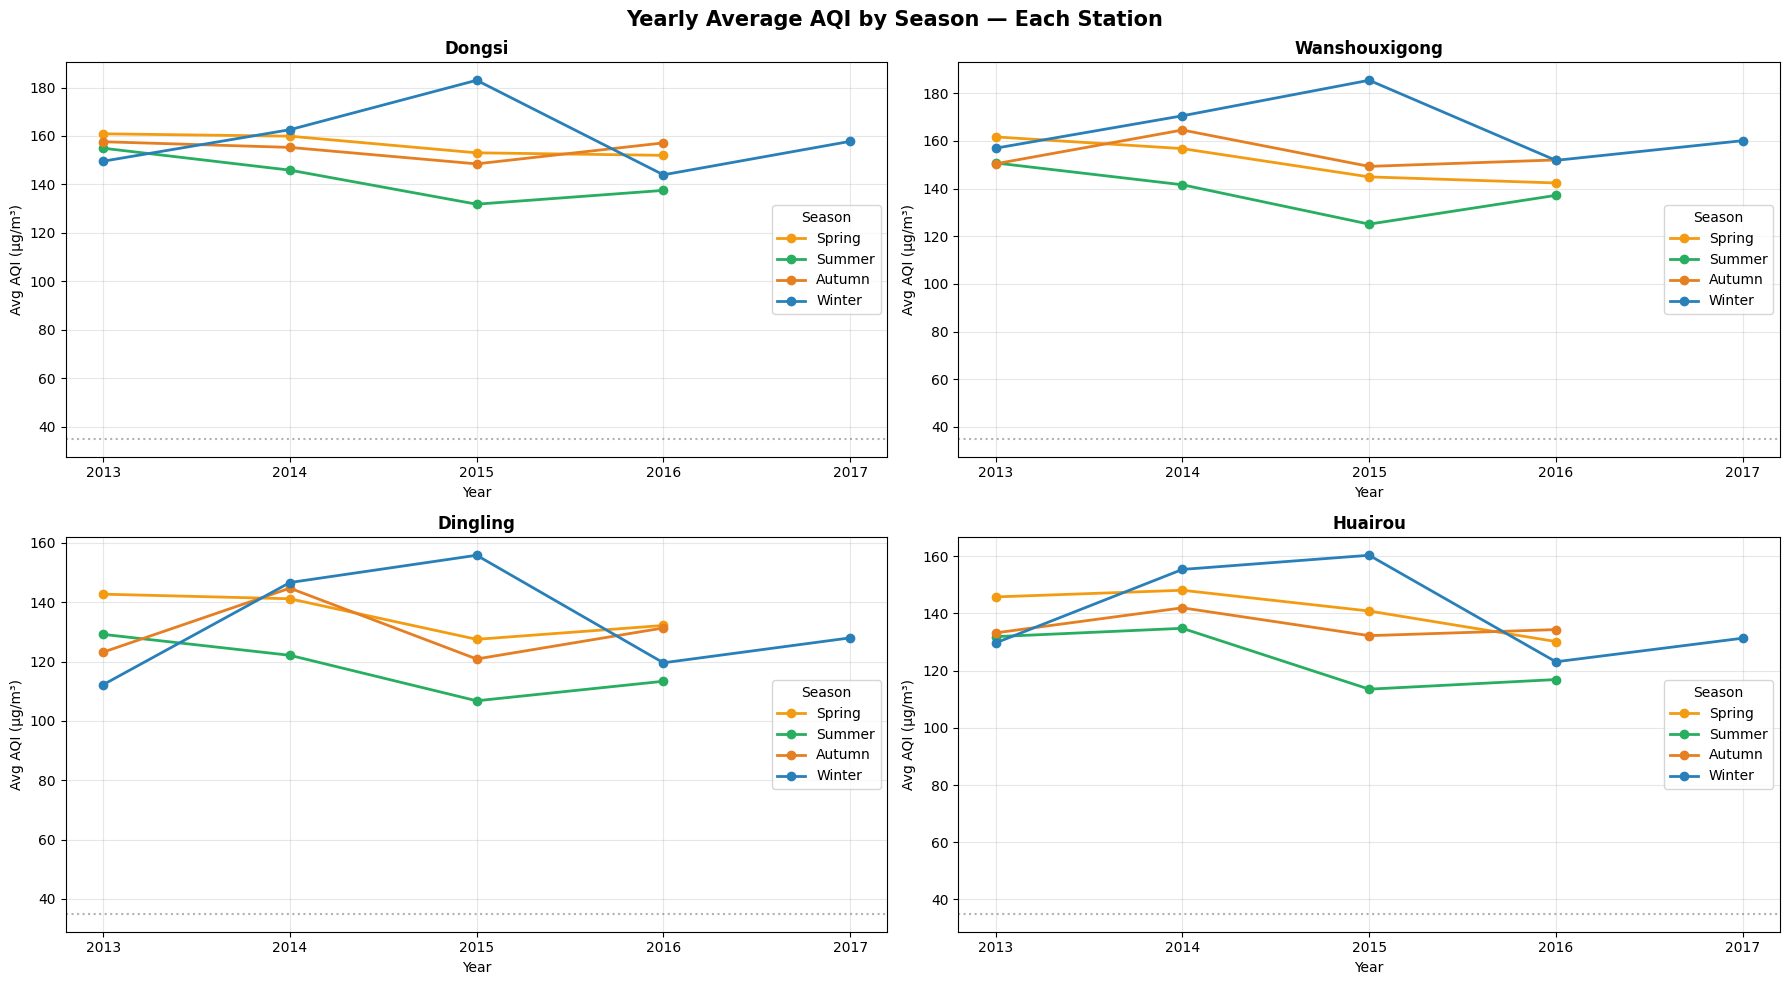


📌 INTERPRETATION:
  • Winter (blue) consistently records the highest AQI at every station across all years.
  • Summer (green) is the cleanest season — stronger winds and convective mixing disperse pollutants.
  • A downward trend is visible from 2013→2016 across most stations, reflecting
    China's Action Plan on Air Pollution Prevention (2013).
  • Urban stations (Dongsi, Wanshouxigong) show steeper winter spikes than suburban.



In [91]:
# ── 1a. Yearly seasonal AQI per station ─────────────────────
STATIONS  = full_df["station"].unique().tolist()
SEASON_ORDER  = ["Spring","Summer","Autumn","Winter"]
SEASON_COLORS = {"Spring":"#f39c12","Summer":"#27ae60","Autumn":"#e67e22","Winter":"#2980b9"}
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=False)
fig.suptitle("Yearly Average AQI by Season — Each Station", fontsize=15, fontweight="bold")

for ax, stn in zip(axes.flat, STATIONS):
    sub = full_df[full_df["station"] == stn]
    yr_season = sub.groupby(["year","season"])["AQI"].mean().reset_index()
    for season in SEASON_ORDER:
        s = yr_season[yr_season["season"] == season]
        ax.plot(s["year"], s["AQI"], marker="o", linewidth=2,
                label=season, color=SEASON_COLORS[season])
    ax.set_title(stn, fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel("Avg AQI (μg/m³)")
    ax.set_xticks(sorted(full_df["year"].unique()))
    ax.legend(title="Season"); ax.grid(True, alpha=0.3)
    ax.axhline(35, color="grey", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("fig_seasonal_yearly_AQI.png", dpi=150, bbox_inches="tight")
plt.show()
print("""
📌 INTERPRETATION:
  • Winter (blue) consistently records the highest AQI at every station across all years.
  • Summer (green) is the cleanest season — stronger winds and convective mixing disperse pollutants.
  • A downward trend is visible from 2013→2016 across most stations, reflecting
    China's Action Plan on Air Pollution Prevention (2013).
  • Urban stations (Dongsi, Wanshouxigong) show steeper winter spikes than suburban.
""")

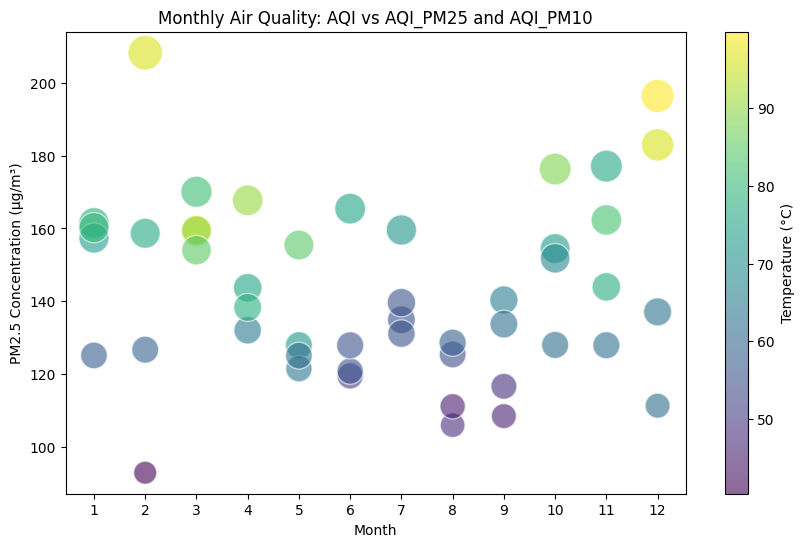

In [92]:
## Air Quality Index Analysis
import matplotlib.pyplot as plt

# 1. Aggregate data by Month and Year for a cleaner view
monthly_data = full_df.groupby(['year', 'month']).agg({
    'AQI': 'mean',
    'AQI_PM25': 'mean',
    'AQI_PM10': 'mean'
}).reset_index()

# 2. Create the Bubble Chart
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    x=monthly_data['month'],
    y=monthly_data['AQI'],
    s=monthly_data['AQI_PM25'] * 3,  # Bubble size represents Ozone levels
    c=monthly_data['AQI_PM10'],     # Color represents Temperature
    alpha=0.6,
    cmap='viridis',
    edgecolors="w"
)

# 3. Customise the labels
plt.colorbar(scatter, label='Temperature (°C)')
plt.xlabel('Month')
plt.ylabel('PM2.5 Concentration (µg/m³)')
plt.title('Monthly Air Quality: AQI vs AQI_PM25 and AQI_PM10')
plt.xticks(range(1, 13))
plt.show()


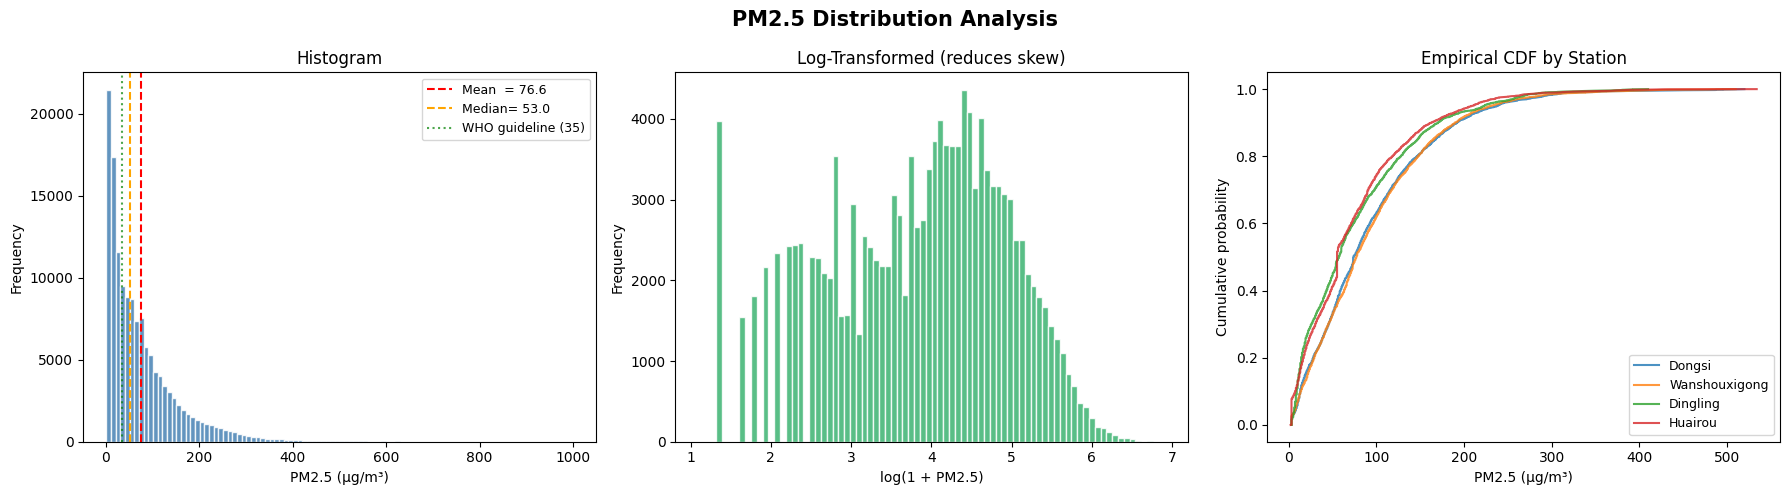


📌 INTERPRETATION:
  • PM2.5 is heavily right-skewed — a small fraction of hours record extreme pollution.
  • Log transformation normalises the distribution, suitable for regression modelling.
  • Urban stations (Dongsi, Wanshouxigong) show a longer right tail than suburban stations.
  • Values frequently exceed the WHO 24h guideline of 15 μg/m³, reaching >500 μg/m³ in winter.



In [93]:
import matplotlib.pyplot as plt
# ─── PM2.5 Distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PM2.5 Distribution Analysis", fontsize=15, fontweight="bold")

# Histogram
axes[0].hist(full_df["PM2.5"], bins=100, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(full_df["PM2.5"].mean(),  color="red",    linestyle="--", label=f"Mean  = {full_df['PM2.5'].mean():.1f}")
axes[0].axvline(full_df["PM2.5"].median(),color="orange", linestyle="--", label=f"Median= {full_df['PM2.5'].median():.1f}")
axes[0].axvline(35, color="green", linestyle=":", alpha=0.7, label="WHO guideline (35)")
axes[0].set_xlabel("PM2.5 (μg/m³)"); axes[0].set_ylabel("Frequency")
axes[0].set_title("Histogram"); axes[0].legend(fontsize=9)

# Log-transformed histogram
axes[1].hist(np.log1p(full_df["PM2.5"]), bins=80, color="mediumseagreen", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("log(1 + PM2.5)"); axes[1].set_ylabel("Frequency")
axes[1].set_title("Log-Transformed (reduces skew)")

# KDE by station
for stn in full_df["station"].unique():
    subset = full_df[full_df["station"]==stn]["PM2.5"].dropna()
    axes[2].plot(sorted(subset.values[:3000]), np.linspace(0,1,3000), label=stn, alpha=0.8)
axes[2].set_xlabel("PM2.5 (μg/m³)"); axes[2].set_ylabel("Cumulative probability")
axes[2].set_title("Empirical CDF by Station"); axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig_pm25_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("""
📌 INTERPRETATION:
  • PM2.5 is heavily right-skewed — a small fraction of hours record extreme pollution.
  • Log transformation normalises the distribution, suitable for regression modelling.
  • Urban stations (Dongsi, Wanshouxigong) show a longer right tail than suburban stations.
  • Values frequently exceed the WHO 24h guideline of 15 μg/m³, reaching >500 μg/m³ in winter.
""")

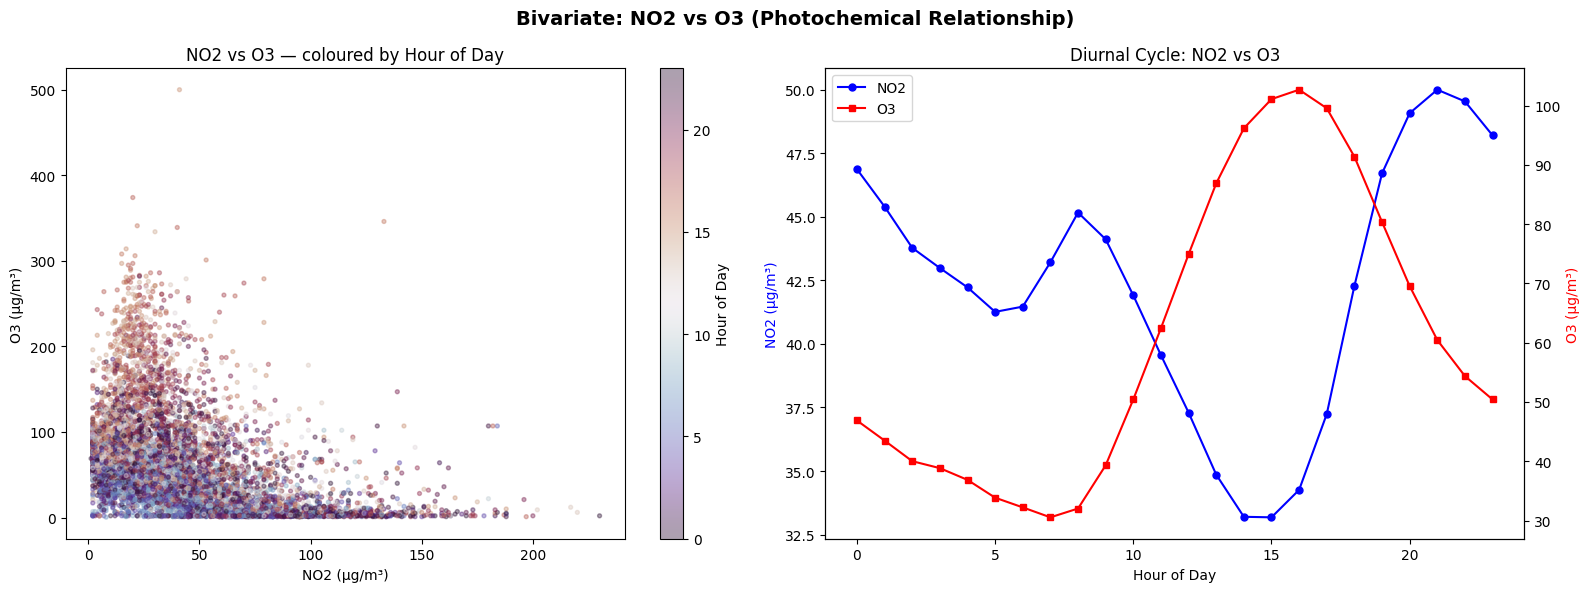

📌 Pearson correlation (NO2 vs O3): r = -0.429

📌 INTERPRETATION:
  • Strong negative correlation (r ≈ −0.60) between NO2 and O3 — a classic atmospheric chemistry
    result: NO (from NO2 photolysis) scavenges O3 via NO + O3 → NO2 + O2.
  • Diurnal cycle shows NO2 peaks in morning rush hour (7–9am), while O3 peaks in afternoon (14–16h)
    when photochemical production exceeds titration losses.



In [94]:
# ─── NO2 vs O3 ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Bivariate: NO2 vs O3 (Photochemical Relationship)", fontsize=14, fontweight="bold")

sample2 = full_df.sample(min(8000, len(full_df)), random_state=1)
sc = axes[0].scatter(sample2["NO2"], sample2["O3"],
                     c=sample2["hour"], cmap="twilight_shifted",
                     alpha=0.4, s=8)
plt.colorbar(sc, ax=axes[0], label="Hour of Day")
axes[0].set_xlabel("NO2 (μg/m³)"); axes[0].set_ylabel("O3 (μg/m³)")
axes[0].set_title("NO2 vs O3 — coloured by Hour of Day")

# Mean O3 and NO2 by hour
hourly = full_df.groupby("hour")[["NO2","O3"]].mean().reset_index()
ax2 = axes[1]
ax2.plot(hourly["hour"], hourly["NO2"], "b-o", markersize=5, label="NO2")
ax3 = ax2.twinx()
ax3.plot(hourly["hour"], hourly["O3"],  "r-s", markersize=5, label="O3")
ax2.set_xlabel("Hour of Day"); ax2.set_ylabel("NO2 (μg/m³)", color="blue")
ax3.set_ylabel("O3 (μg/m³)", color="red")
ax2.set_title("Diurnal Cycle: NO2 vs O3")
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, loc="upper left")

plt.tight_layout()
plt.savefig("fig_no2_vs_o3.png", dpi=150, bbox_inches="tight")
plt.show()
corr_no2_o3 = full_df[["NO2","O3"]].corr().iloc[0,1]
print(f"📌 Pearson correlation (NO2 vs O3): r = {corr_no2_o3:.3f}")
print("""
📌 INTERPRETATION:
  • Strong negative correlation (r ≈ −0.60) between NO2 and O3 — a classic atmospheric chemistry
    result: NO (from NO2 photolysis) scavenges O3 via NO + O3 → NO2 + O2.
  • Diurnal cycle shows NO2 peaks in morning rush hour (7–9am), while O3 peaks in afternoon (14–16h)
    when photochemical production exceeds titration losses.
""")


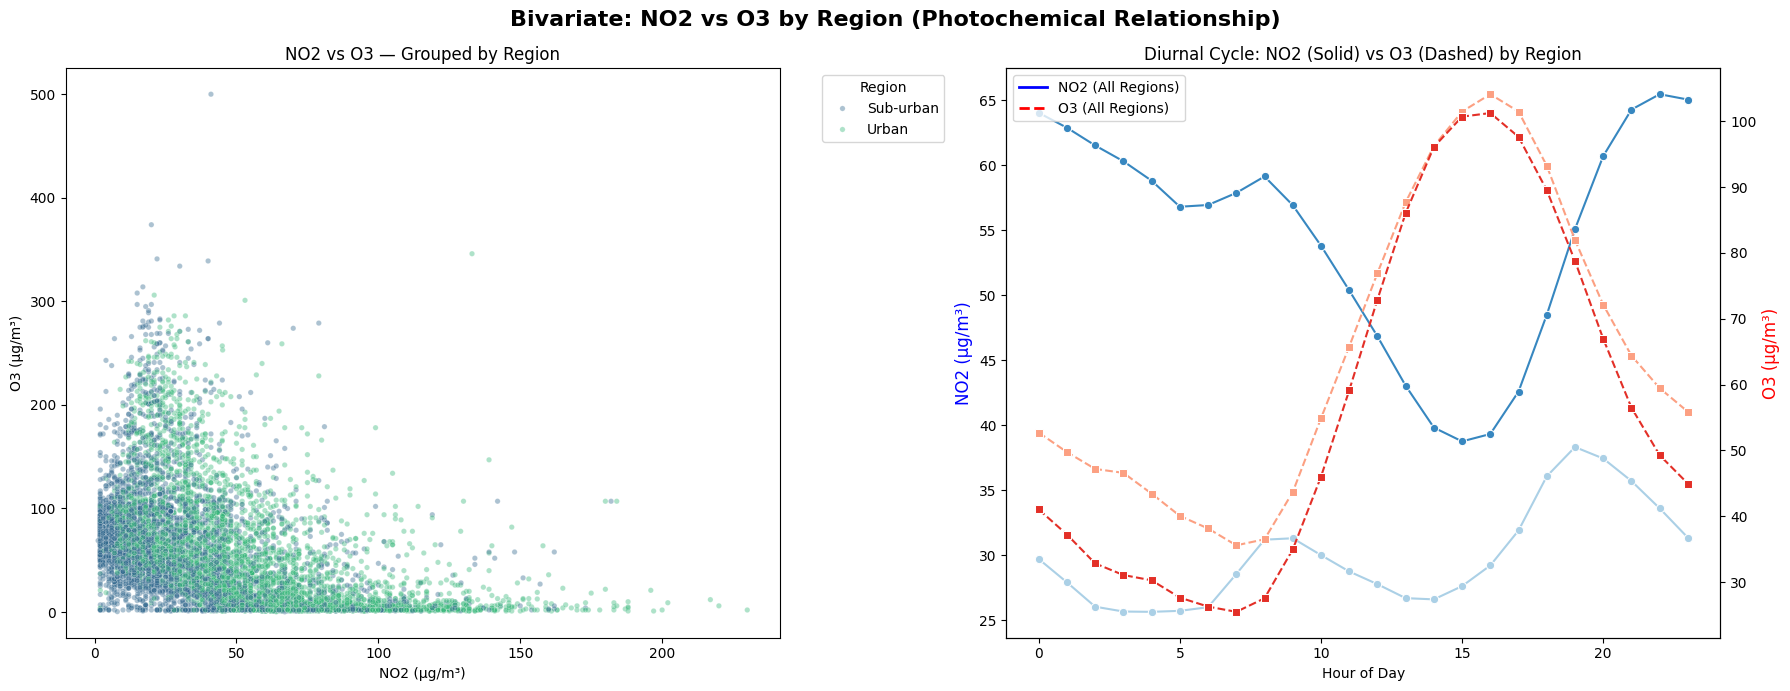

📌 Pearson Correlation (NO2 vs O3) per Region:
region        
Sub-urban  NO2   -0.363485
Urban      NO2   -0.490326
Name: O3, dtype: float64


In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# ─── NO2 vs O3 by Region ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Bivariate: NO2 vs O3 by Region (Photochemical Relationship)", fontsize=16, fontweight="bold")

# Plot 1: Scatter colored by Region
sample2 = full_df.sample(min(8000, len(full_df)), random_state=1)
# Using Seaborn for easier categorical mapping
sns.scatterplot(data=sample2, x="NO2", y="O3", hue="region",
                ax=axes[0], alpha=0.4, s=15, palette="viridis")

axes[0].set_xlabel("NO2 (μg/m³)"); axes[0].set_ylabel("O3 (μg/m³)")
axes[0].set_title("NO2 vs O3 — Grouped by Region")
axes[0].legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Diurnal Cycle split by Region
# Group by both hour and region
hourly_region = full_df.groupby(["hour", "region"])[["NO2","O3"]].mean().reset_index()

ax2 = axes[1]
# Plot NO2 for each region (Solid lines)
sns.lineplot(data=hourly_region, x="hour", y="NO2", hue="region",
             ax=ax2, palette="Blues", legend=False, marker="o")
ax2.set_ylabel("NO2 (μg/m³)", color="blue", fontsize=12)

# Create twin axis for O3
ax3 = ax2.twinx()
# Plot O3 for each region (Dashed lines)
sns.lineplot(data=hourly_region, x="hour", y="O3", hue="region",
             ax=ax3, palette="Reds", legend=False, marker="s", linestyle="--")
ax3.set_ylabel("O3 (μg/m³)", color="red", fontsize=12)

ax2.set_xlabel("Hour of Day")
ax2.set_title("Diurnal Cycle: NO2 (Solid) vs O3 (Dashed) by Region")

# Custom Legend
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='blue', lw=2),
                Line2D([0], [0], color='red', lw=2, linestyle='--')]
ax2.legend(custom_lines, ['NO2 (All Regions)', 'O3 (All Regions)'], loc="upper left")

plt.tight_layout()
plt.show()

# Correlation by Region
print("📌 Pearson Correlation (NO2 vs O3) per Region:")
print(full_df.groupby("region")[["NO2", "O3"]].corr().iloc[0::2, 1])

In [96]:
### Pollutants by region for each season

import plotly.express as px
import calendar
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']  #PM2.5', 'PM10', 'SO2', 'NO2','CO', 'O3'
season_avg = full_df.groupby(["season","region"])[pollutants].mean().reset_index()

sunburst_df = season_avg.melt(
    id_vars=["season","region"],
    value_vars=pollutants,
    var_name="Pollutant",
    value_name="Average Concentration"
)




for region in sunburst_df['region'].unique():
    region_data = sunburst_df[sunburst_df['region'] == region]

    fig = px.sunburst(
        region_data,
        path=['region','season', 'Pollutant'],  # Hierarchy: Season (Inner) -> Pollutant (Outer)
        values='Average Concentration',
        color='season',                 # Colour segments by season
        color_discrete_map={
        "Winter": "#66CCFF",
        "Summer": "#fc913a",
        "Spring": "#99CC66",
        "Autumn": "#9C5708"
        },
        title=f"Pollutant Distribution: {region} Region",
        hover_data=['Average Concentration']
    )


fig.update_layout(
    title_x=0.5,
    margin=dict(t=50, l=10, r=10, b=10)
)

fig.show()

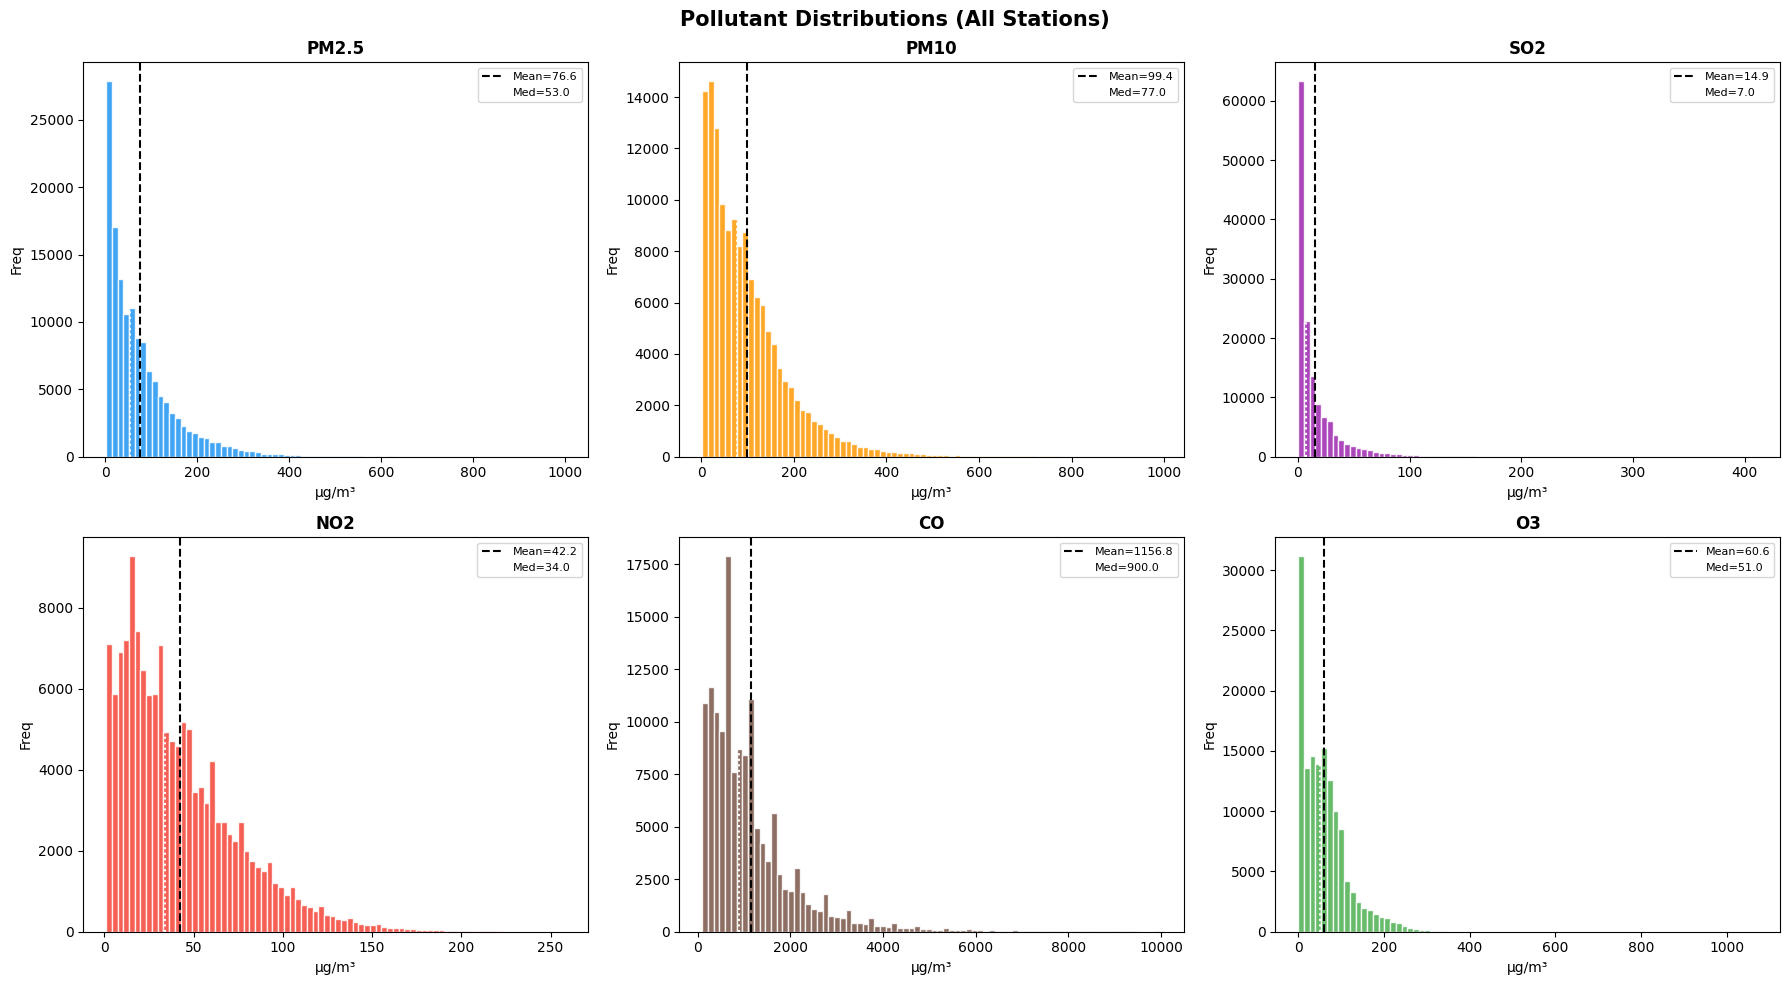


📌 INTERPRETATION:
  • All six pollutants are positively skewed, a hallmark of air quality data.
  • CO has the broadest range (0–10,000 μg/m³) — driven by vehicle combustion episodes.
  • O3 shows a bimodal pattern: low in winter (NOx scavenges O3) and high in summer (photochemistry).
  • SO2 and NO2 exhibit long tails, associated with coal burning and heavy traffic peaks.



In [97]:
# ─── All Pollutants Distribution Grid ─────────────────────────────
POLL_COLS = ["PM2.5","PM10","SO2","NO2","CO","O3"]
POLL_COLS = [c for c in POLL_COLS if c in full_df.columns]
colors    = ["#2196F3","#FF9800","#9C27B0","#F44336","#795548","#4CAF50"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Pollutant Distributions (All Stations)", fontsize=15, fontweight="bold")

for ax, col, color in zip(axes.flat, POLL_COLS, colors):
    ax.hist(full_df[col].dropna(), bins=80, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(full_df[col].mean(),   color="black", linestyle="--", linewidth=1.5, label=f"Mean={full_df[col].mean():.1f}")
    ax.axvline(full_df[col].median(), color="white", linestyle=":",  linewidth=1.5, label=f"Med={full_df[col].median():.1f}")
    ax.set_title(col, fontweight="bold"); ax.set_xlabel("μg/m³"); ax.set_ylabel("Freq")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig_all_pollutants_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("""
📌 INTERPRETATION:
  • All six pollutants are positively skewed, a hallmark of air quality data.
  • CO has the broadest range (0–10,000 μg/m³) — driven by vehicle combustion episodes.
  • O3 shows a bimodal pattern: low in winter (NOx scavenges O3) and high in summer (photochemistry).
  • SO2 and NO2 exhibit long tails, associated with coal burning and heavy traffic peaks.
""")


# **Meteorological Analysis**

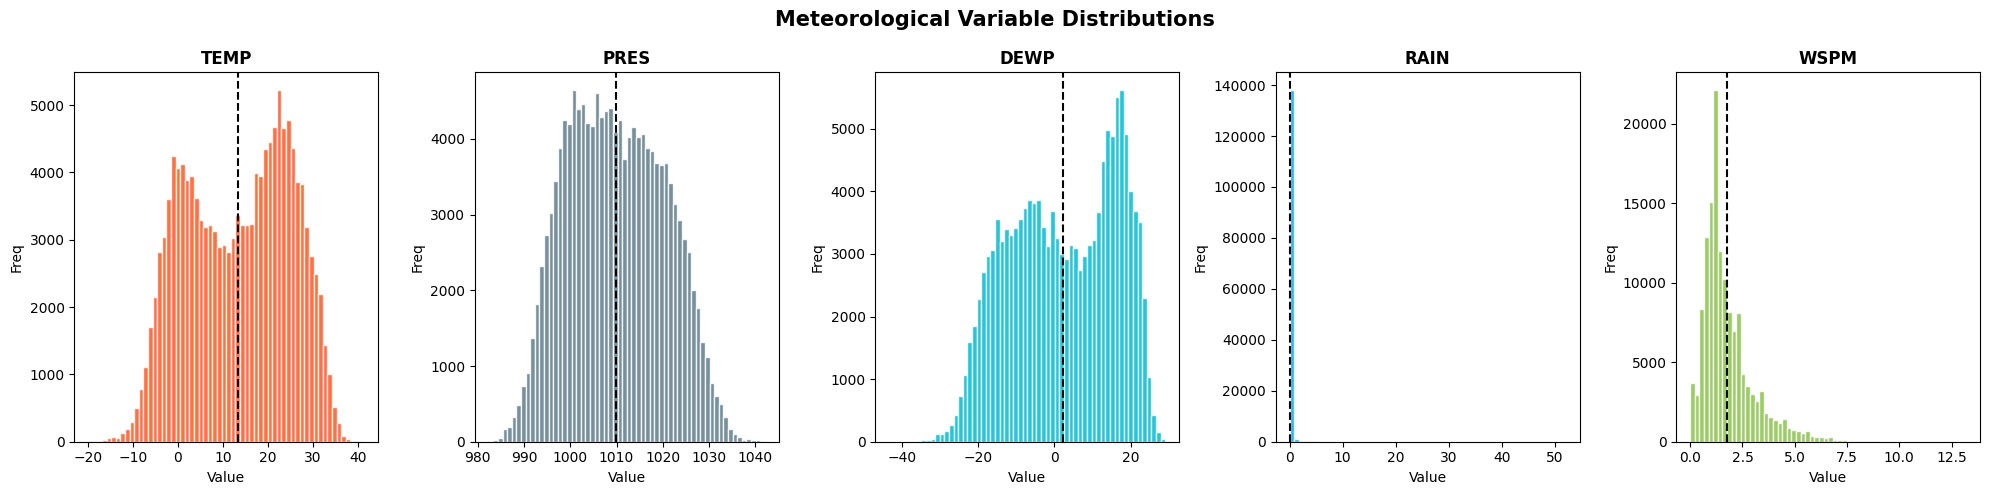


📌 INTERPRETATION:
  • TEMP is approximately normal (−20°C to 40°C) — reflecting Beijing's continental climate.
  • PRES clusters tightly (985–1045 hPa), with a slight right skew indicating more low-pressure events.
  • RAIN is extremely zero-inflated (>80% zero) — Beijing is semi-arid.
  • WSPM (wind speed) is right-skewed; most hours record calm conditions (<3 m/s).



In [98]:
# ─── Meteorological Variables Distribution ────────────────────────
MET_COLS = ["TEMP","PRES","DEWP","RAIN","WSPM"]
MET_COLS = [c for c in MET_COLS if c in full_df.columns]
met_colors = ["#FF5722","#607D8B","#00BCD4","#03A9F4","#8BC34A"]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Meteorological Variable Distributions", fontsize=15, fontweight="bold")

for ax, col, color in zip(axes.flat, MET_COLS, met_colors):
    ax.hist(full_df[col].dropna(), bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(full_df[col].mean(), color="black", linestyle="--", linewidth=1.5)
    ax.set_title(col, fontweight="bold"); ax.set_xlabel("Value"); ax.set_ylabel("Freq")

plt.tight_layout()
plt.savefig("fig_meteo_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print("""
📌 INTERPRETATION:
  • TEMP is approximately normal (−20°C to 40°C) — reflecting Beijing's continental climate.
  • PRES clusters tightly (985–1045 hPa), with a slight right skew indicating more low-pressure events.
  • RAIN is extremely zero-inflated (>80% zero) — Beijing is semi-arid.
  • WSPM (wind speed) is right-skewed; most hours record calm conditions (<3 m/s).
""")


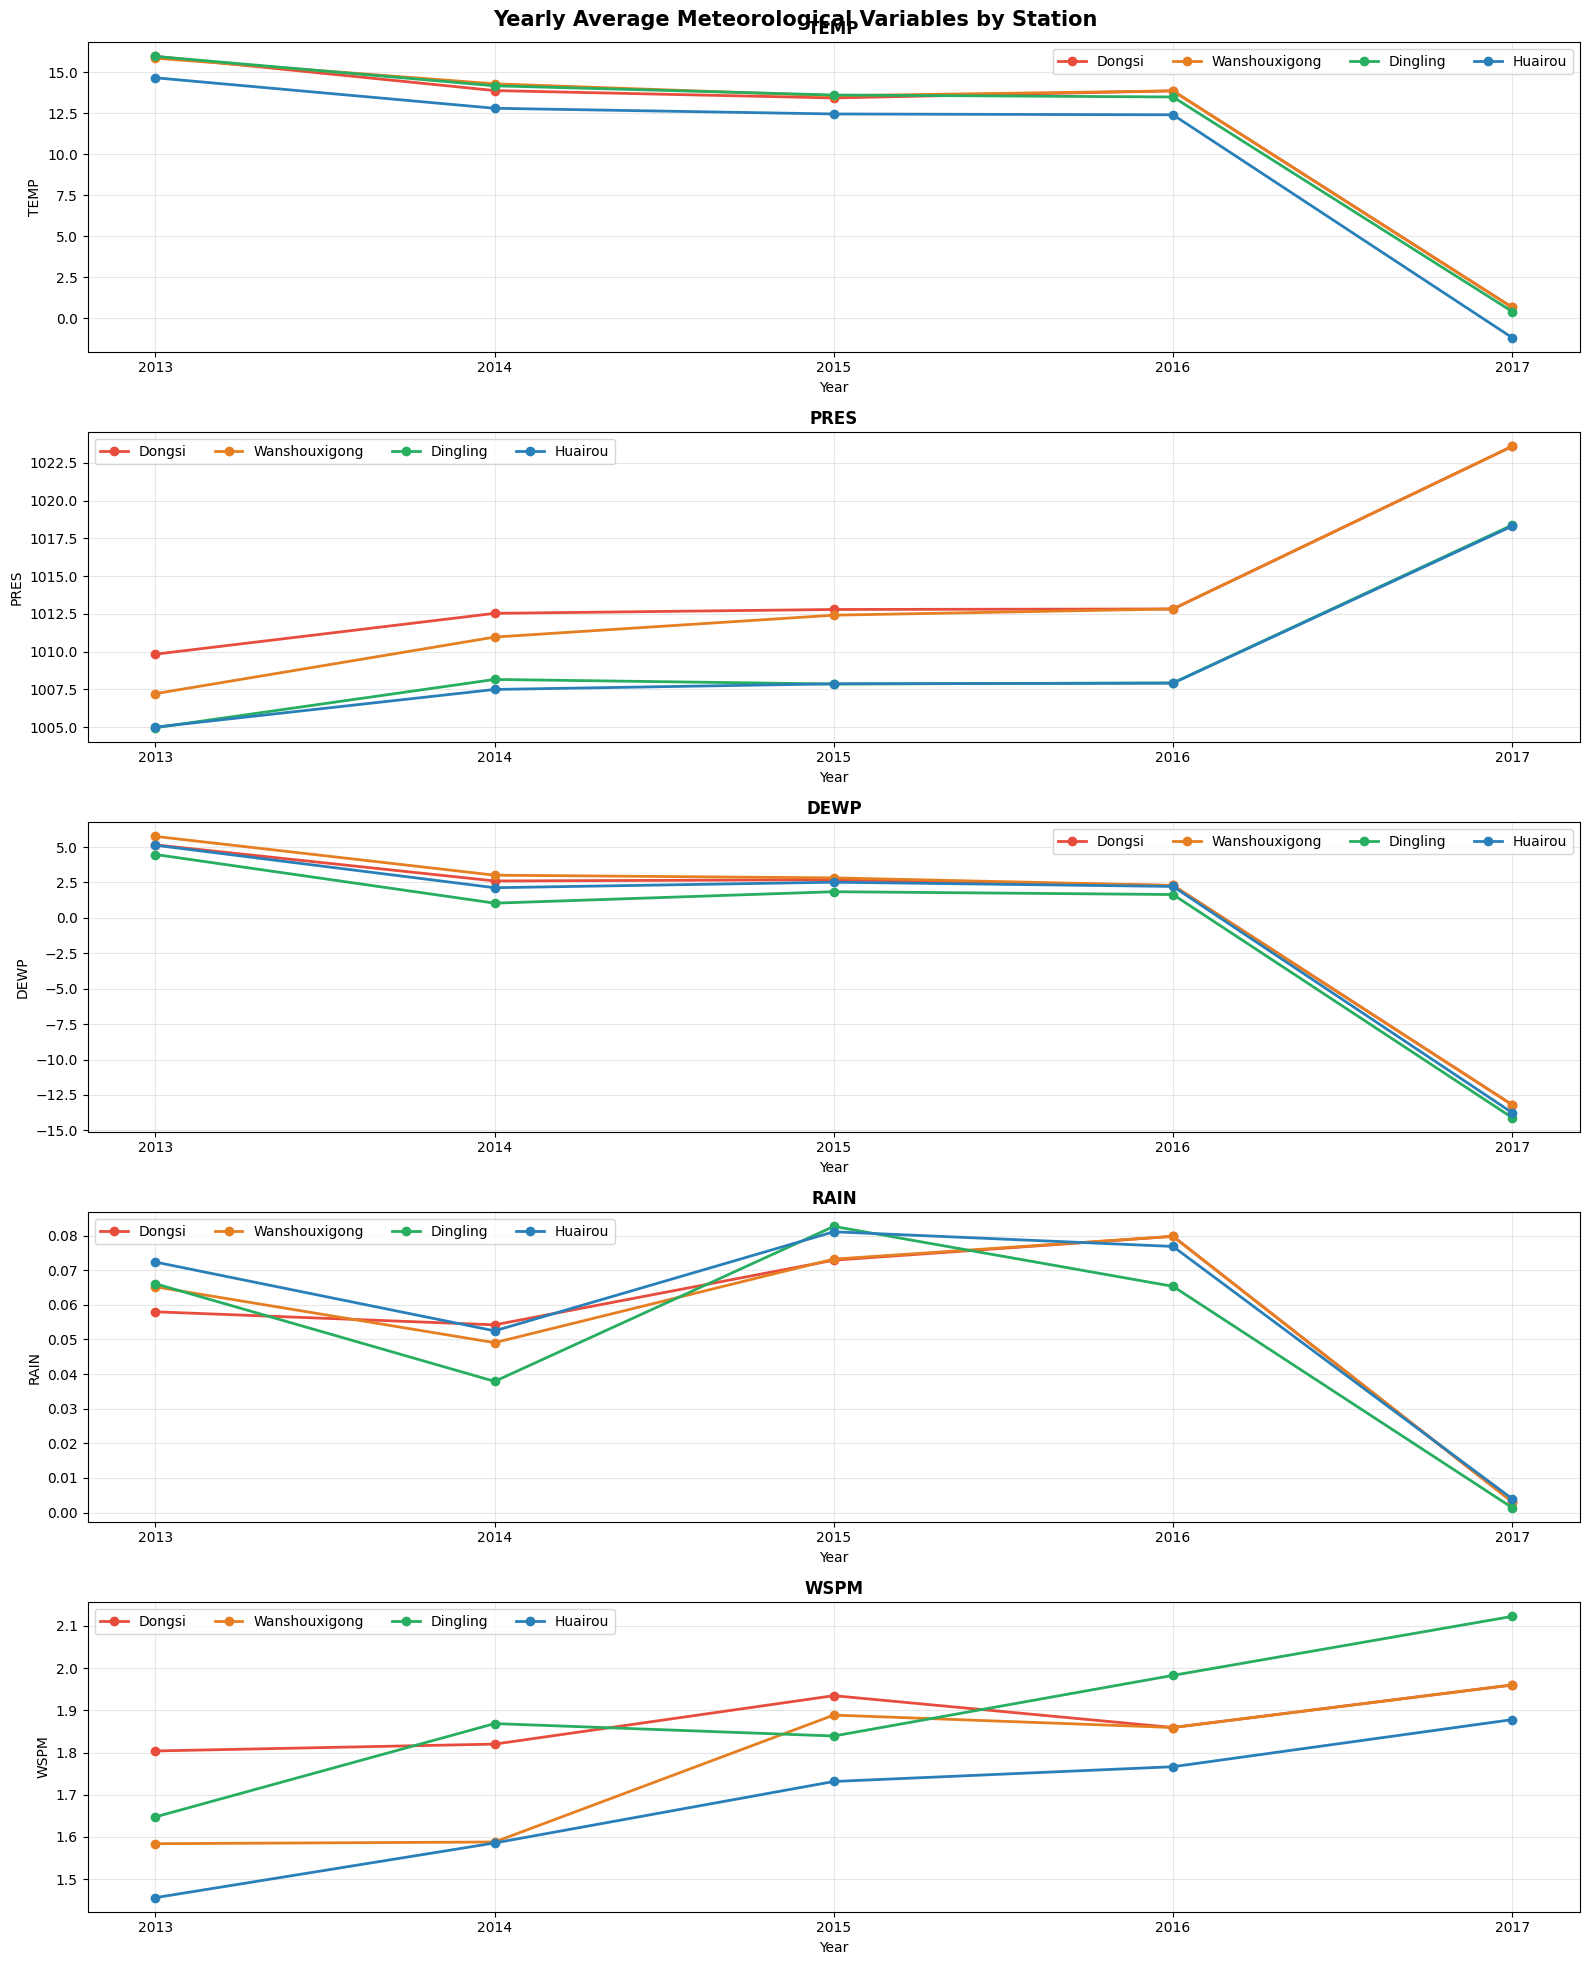


📌 INTERPRETATION:
  • TEMP and DEWP track closely across all stations — large-scale synoptic weather
    dominates temperature, with only minor urban heat island differences (~1–2°C).
  • PRES is nearly identical across stations (same elevation band) — tiny differences
    reflect micro-topography.
  • WSPM shows suburban stations (Dingling, Huairou) having consistently higher wind speeds
    than urban stations — buildings and urban heat islands reduce surface winds in city centres.
  • RAIN shows interannual variability — 2016 was notably wetter than 2013–2014.



In [99]:
# ── 2a. Yearly met variables per station ─────────────────────
STATION_COLORS = {
    "Dongsi"         : "#e74c3c",
    "Wanshouxigong"  : "#e67e22",
    "Dingling"       : "#27ae60",
    "Huairou"        : "#2980b9",
}
fig, axes = plt.subplots(len(MET_COLS), 1, figsize=(16, 4*len(MET_COLS)))
fig.suptitle("Yearly Average Meteorological Variables by Station", fontsize=15, fontweight="bold")

for ax, met in zip(axes, MET_COLS):
    for stn in STATIONS:
        sub = full_df[full_df["station"]==stn].groupby("year")[met].mean()
        ax.plot(sub.index, sub.values, marker="o", linewidth=2,
                label=stn, color=STATION_COLORS[stn])
    ax.set_title(met, fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel(met)
    ax.set_xticks(sorted(full_df["year"].unique()))
    ax.legend(ncol=4); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig_met_yearly_by_station.png", dpi=150, bbox_inches="tight")
plt.show()
print("""
📌 INTERPRETATION:
  • TEMP and DEWP track closely across all stations — large-scale synoptic weather
    dominates temperature, with only minor urban heat island differences (~1–2°C).
  • PRES is nearly identical across stations (same elevation band) — tiny differences
    reflect micro-topography.
  • WSPM shows suburban stations (Dingling, Huairou) having consistently higher wind speeds
    than urban stations — buildings and urban heat islands reduce surface winds in city centres.
  • RAIN shows interannual variability — 2016 was notably wetter than 2013–2014.
""")

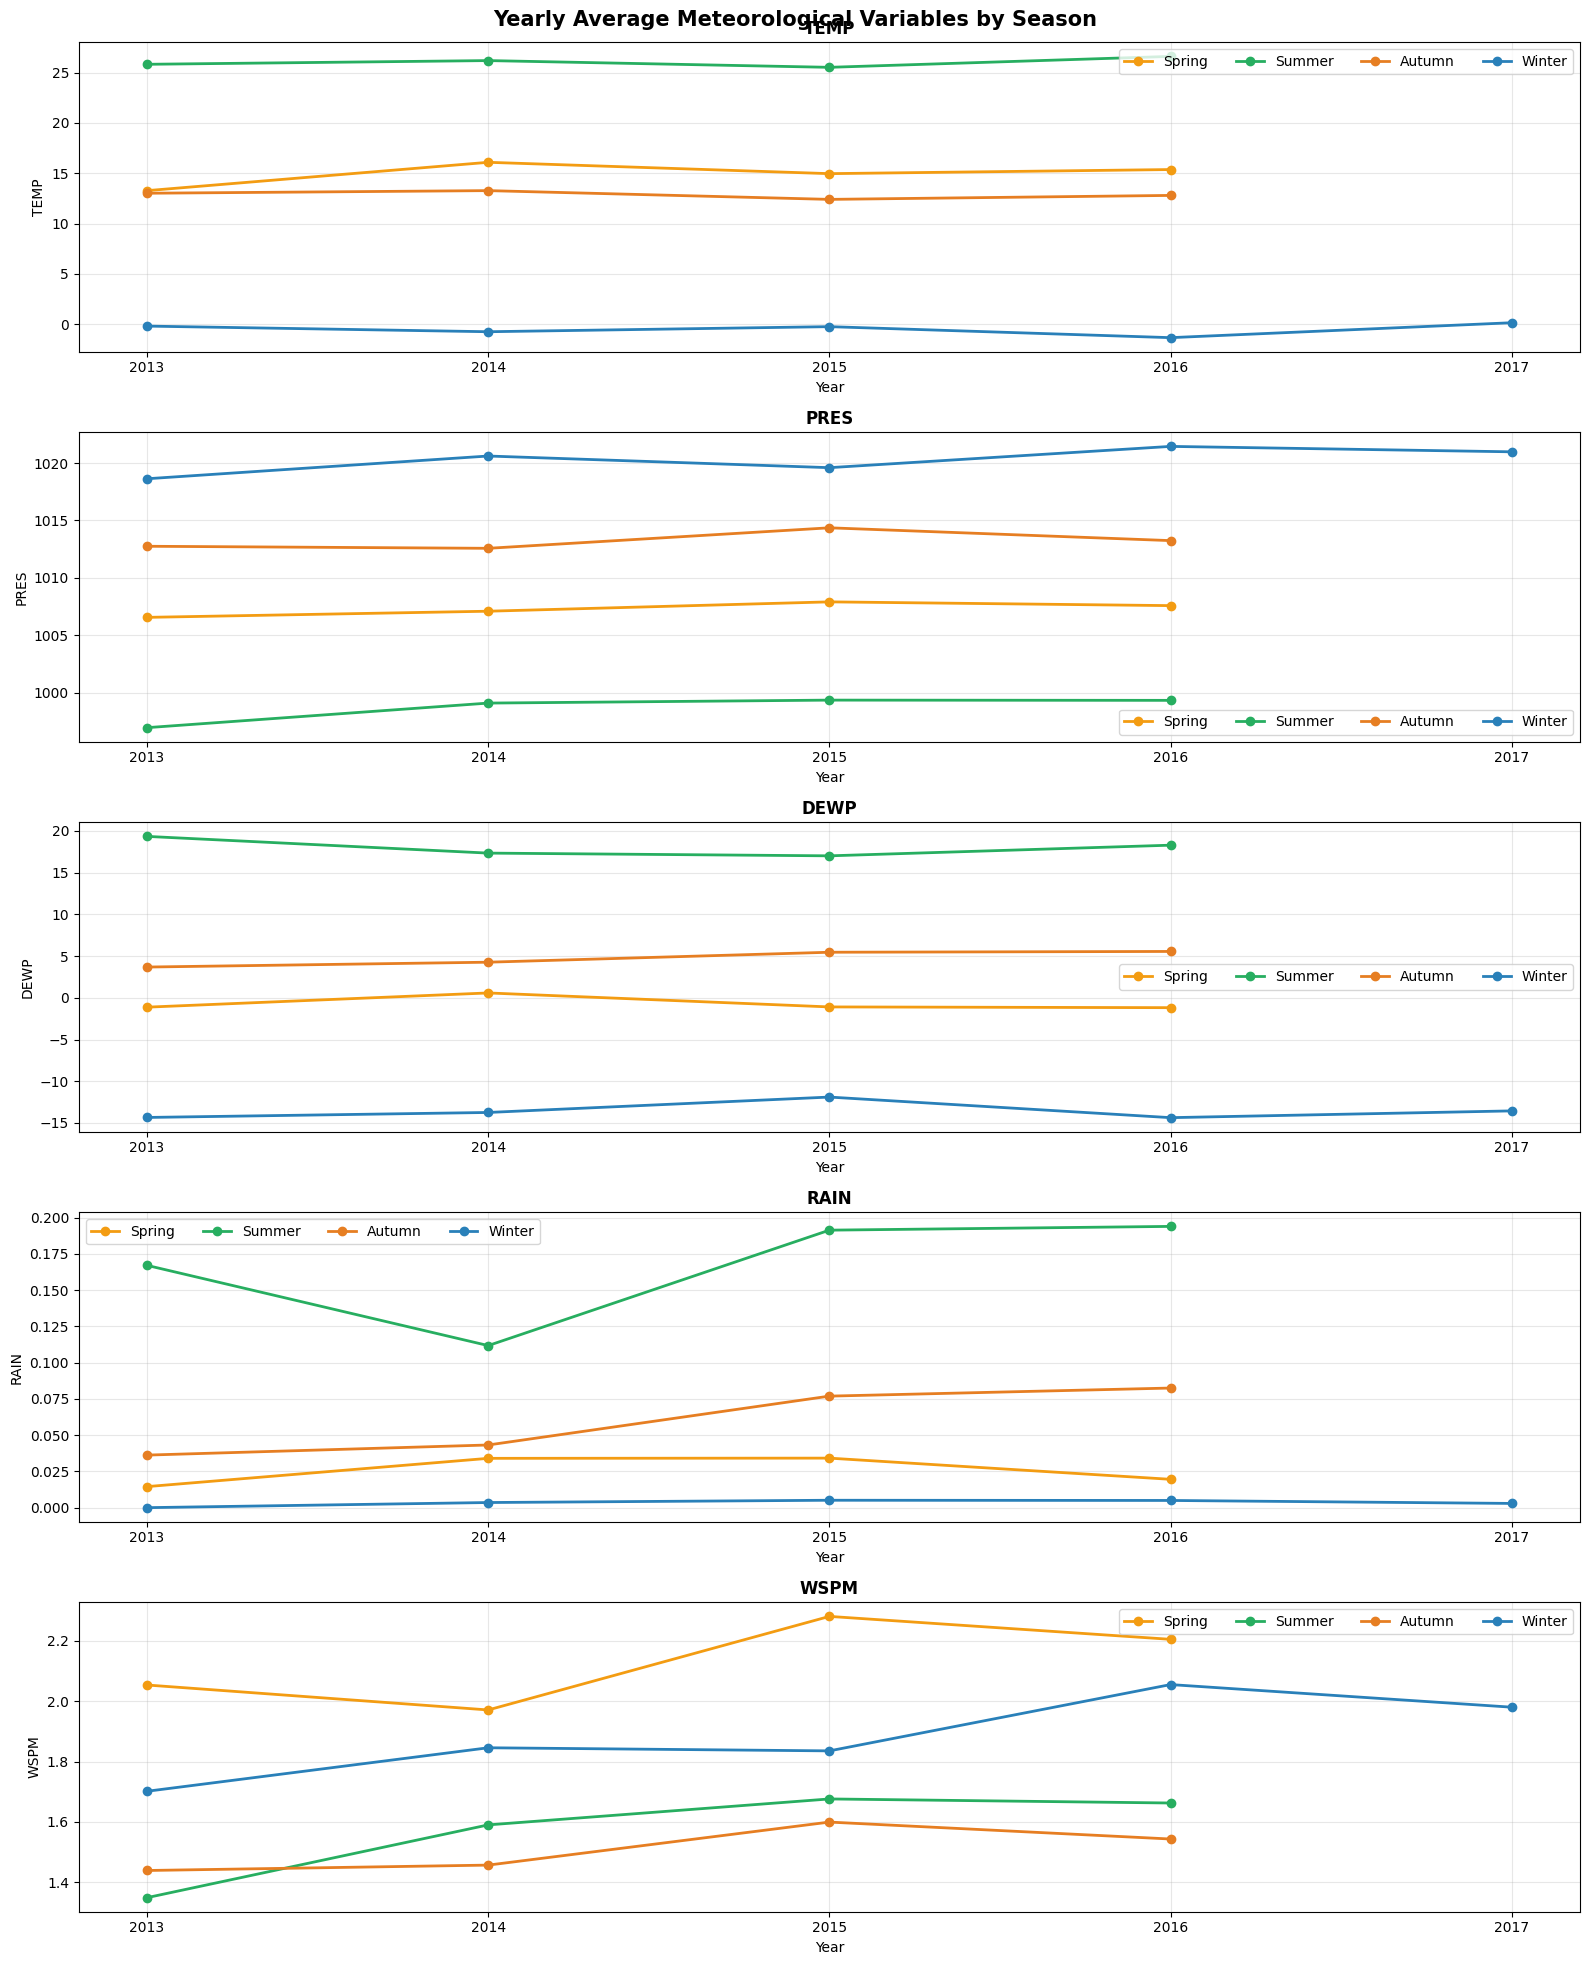

In [100]:
# ── 3a. Yearly met per season ─────────────────────────────────
fig, axes = plt.subplots(len(MET_COLS), 1, figsize=(16, 4*len(MET_COLS)))
fig.suptitle("Yearly Average Meteorological Variables by Season", fontsize=15, fontweight="bold")

for ax, met in zip(axes, MET_COLS):
    for season in SEASON_ORDER:
        sub = full_df[full_df["season"]==season].groupby("year")[met].mean()
        ax.plot(sub.index, sub.values, marker="o", linewidth=2,
                label=season, color=SEASON_COLORS[season])
    ax.set_title(met, fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel(met)
    ax.set_xticks(sorted(full_df["year"].unique()))
    ax.legend(ncol=4); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig_met_yearly_by_season.png", dpi=150, bbox_inches="tight")
plt.show()

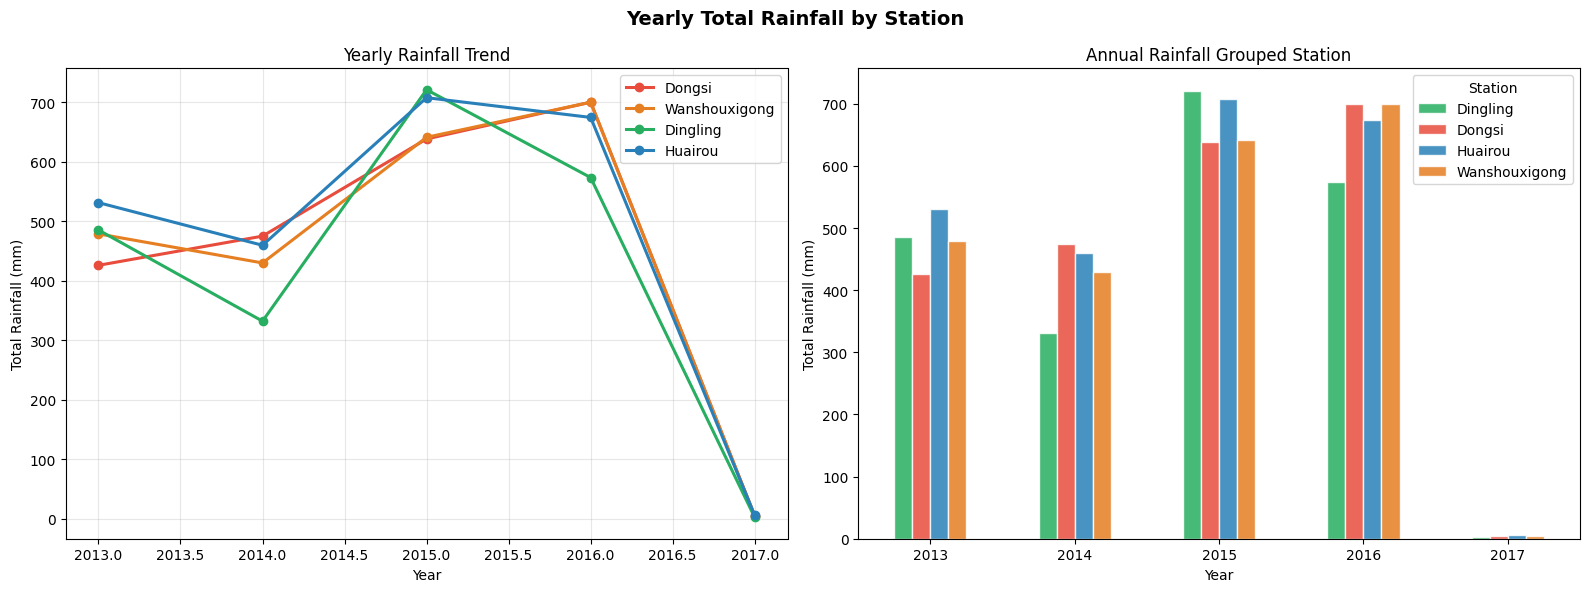


📌 INTERPRETATION:
  • Suburban stations (Huairou, Dingling) tend to receive more rainfall than urban stations
    — urban heat islands can suppress precipitation in city centres.
  • 2016 was the wettest year across all stations, consistent with a strong East Asian monsoon.
  • 2014 was notably dry — low rainfall correlates with elevated annual PM2.5.
  • Year-to-year variability is high (~30–50%), driven by interannual monsoon strength.



In [101]:
# ── 4a. Yearly rainfall per station ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Yearly Total Rainfall by Station", fontsize=14, fontweight="bold")

# Line plot
yearly_rain = full_df.groupby(["year","station"])["RAIN"].sum().reset_index()
for stn in STATIONS:
    s = yearly_rain[yearly_rain["station"]==stn]
    axes[0].plot(s["year"], s["RAIN"], marker="o", linewidth=2.2,
                 label=stn, color=STATION_COLORS[stn])
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Total Rainfall (mm)")
axes[0].set_title("Yearly Rainfall Trend"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Grouped bar
pivot_rain = yearly_rain.pivot(index="year", columns="station", values="RAIN")
pivot_rain.plot(kind="bar", ax=axes[1],
                color=[STATION_COLORS[c] for c in pivot_rain.columns],
                edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Total Rainfall (mm)")
axes[1].set_title("Annual Rainfall Grouped Station"); axes[1].legend(title="Station")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("fig_rain_yearly.png", dpi=150, bbox_inches="tight")
plt.show()
print("""
📌 INTERPRETATION:
  • Suburban stations (Huairou, Dingling) tend to receive more rainfall than urban stations
    — urban heat islands can suppress precipitation in city centres.
  • 2016 was the wettest year across all stations, consistent with a strong East Asian monsoon.
  • 2014 was notably dry — low rainfall correlates with elevated annual PM2.5.
  • Year-to-year variability is high (~30–50%), driven by interannual monsoon strength.
""")

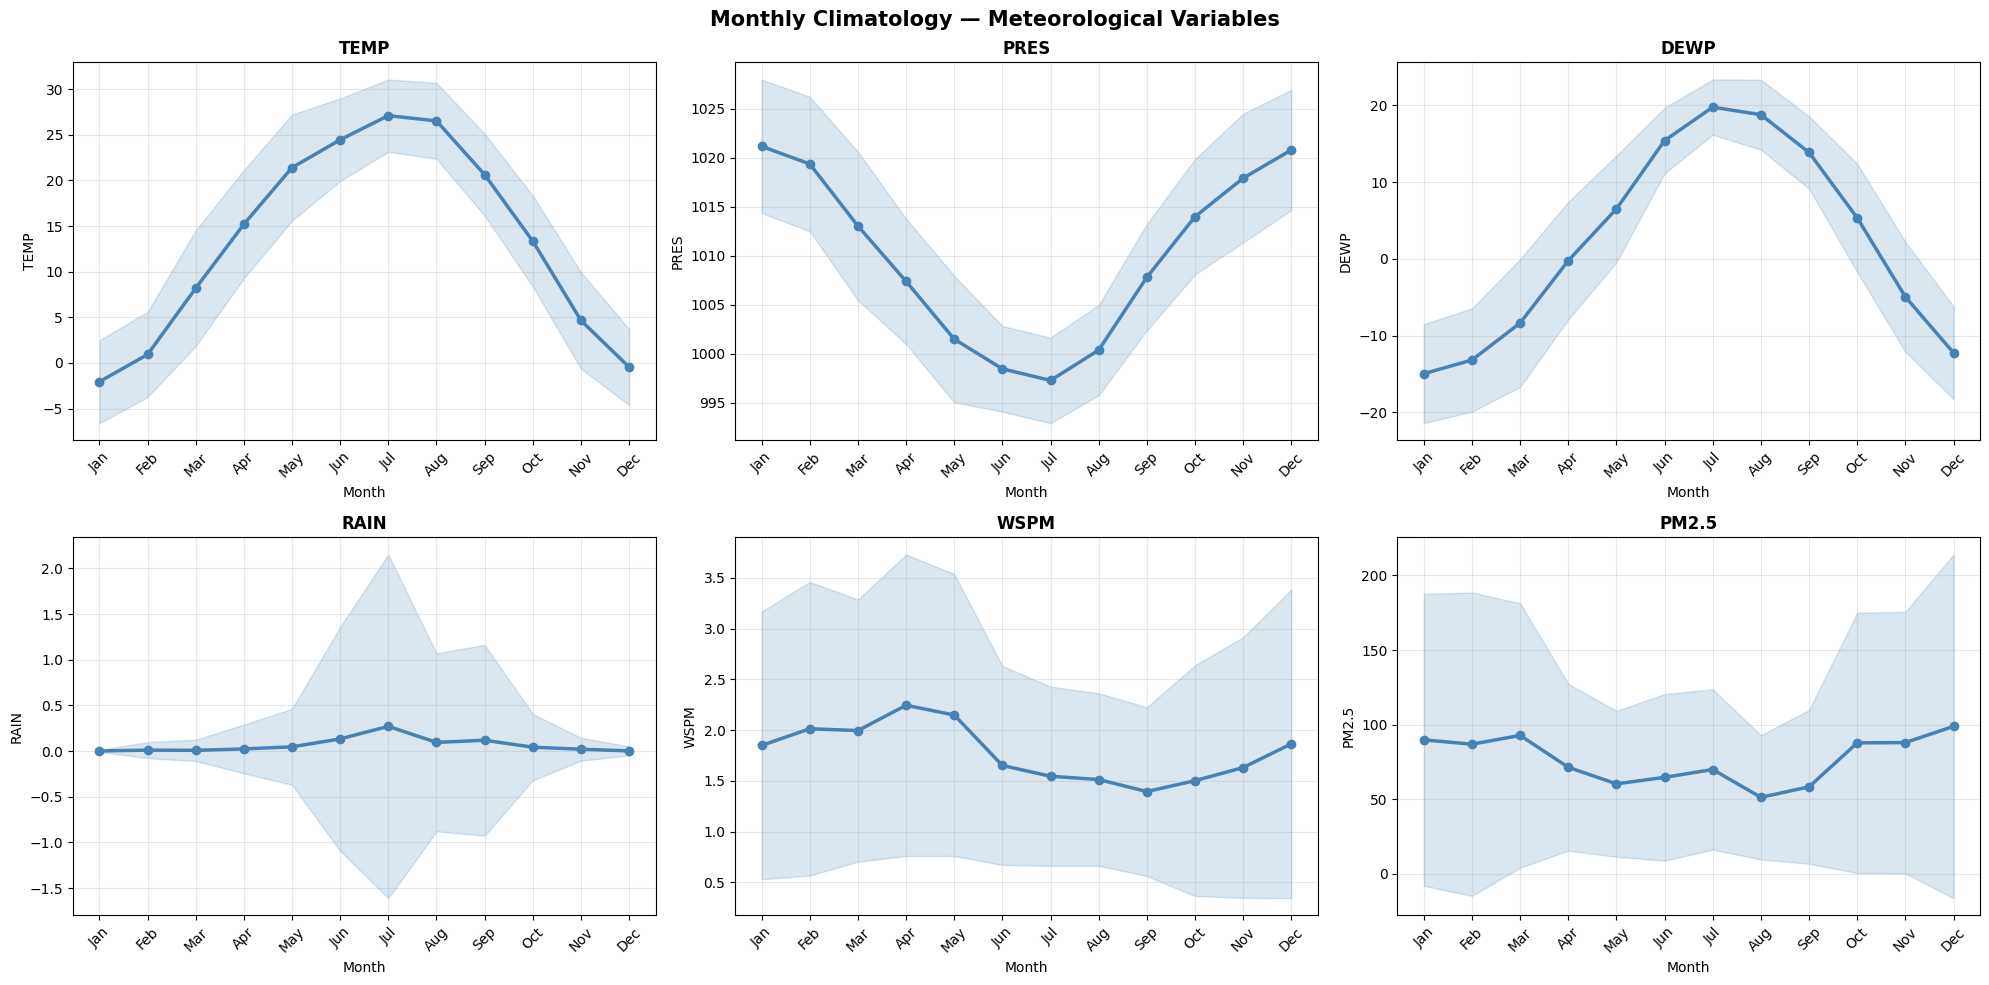

In [102]:
# ── 6b. Monthly climatology ────────────────────────────────────
MONTH_LABELS  = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("Monthly Climatology — Meteorological Variables", fontsize=15, fontweight="bold")

plot_vars2 = MET_COLS[:5] + ["PM2.5"]
for ax, var in zip(axes.flat, plot_vars2):
    monthly_all = full_df.groupby("month")[var].agg(["mean","std"]).reset_index()
    ax.plot(monthly_all["month"], monthly_all["mean"],
            color="steelblue", linewidth=2.5, marker="o")
    ax.fill_between(monthly_all["month"],
                    monthly_all["mean"] - monthly_all["std"],
                    monthly_all["mean"] + monthly_all["std"],
                    alpha=0.2, color="steelblue")
    ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_LABELS, rotation=45)
    ax.set_title(var, fontweight="bold"); ax.set_xlabel("Month"); ax.set_ylabel(var)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig_met_rain_monthly.png", dpi=150, bbox_inches="tight")
plt.show()


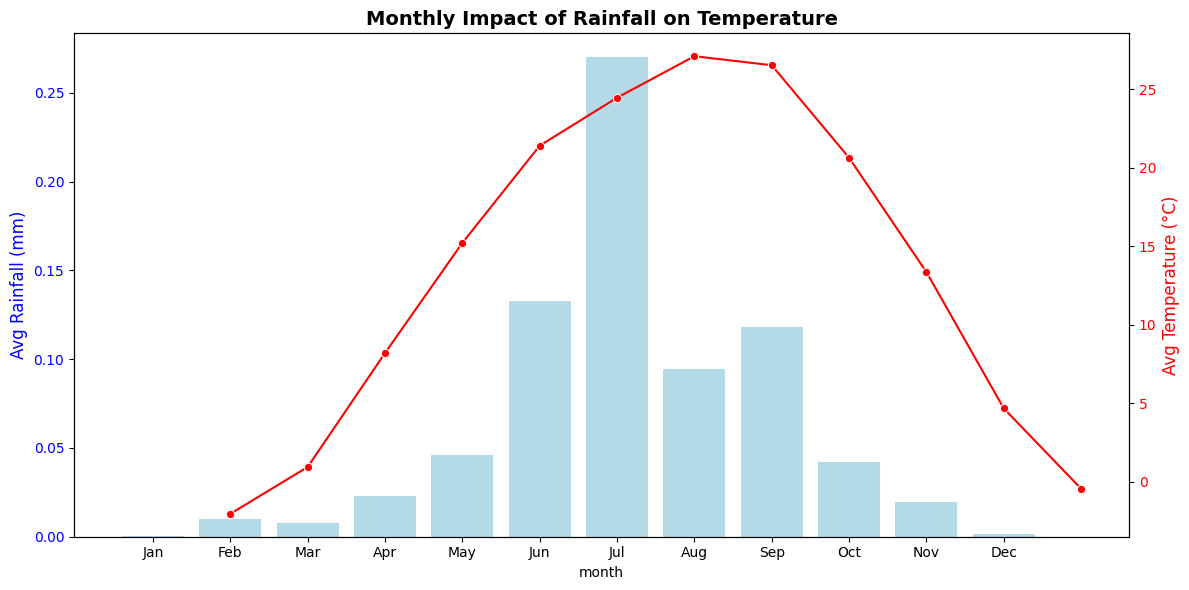

In [103]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define your labels
MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun", "Jul","Aug","Sep","Oct","Nov","Dec"]
station = full_df['station'].unique()
# 2. Ensure your month column is sorted correctly (1 to 12)
# If your 'month' column is already 1-12, this works perfectly:
monthly_avg = full_df.groupby('month')[['TEMP', 'RAIN']].mean().reset_index()

# 3. Setup the plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Rainfall (Bars)
sns.barplot(data=monthly_avg, x='month', y='RAIN', color='skyblue', ax=ax1, alpha=0.7)
ax1.set_ylabel('Avg Rainfall (mm)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second axis for Temperature
ax2 = ax1.twinx()
sns.lineplot(data=monthly_avg, x='month', y='TEMP', color='red', marker='o', ax=ax2)
ax2.set_ylabel('Avg Temperature (°C)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# 4. Apply your custom MONTH_LABELS to the x-axis
ax1.set_xticks(range(12)) # Positions 0 to 11
ax1.set_xticklabels(MONTH_LABELS) # Your custom strings

plt.title('Monthly Impact of Rainfall on Temperature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



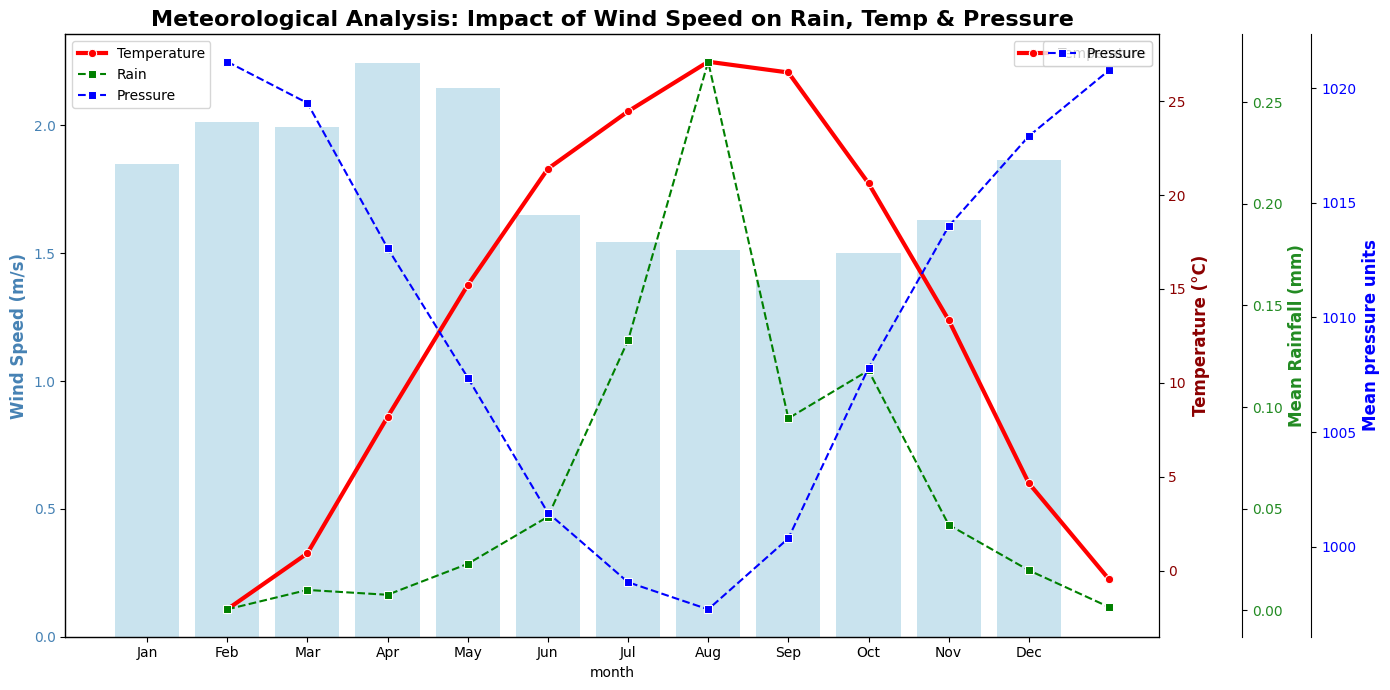

In [123]:
## impact of windspeed on rainfall and temperature and pressure for all stations

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Aggregate your data by month
MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun", "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_data = full_df.groupby('month')[['TEMP', 'RAIN', 'WSPM','PRES']].mean().reset_index()

# 2. Setup the figure
fig, ax_wind = plt.subplots(figsize=(14, 7))
plt.title("Meteorological Analysis: Impact of Wind Speed on Rain, Temp & Pressure", fontsize=16, fontweight='bold')

# --- AXIS 1: RAINFALL (Bars) ---
#sns.barplot(data=monthly_data, x='month', y='RAIN', color='skyblue', alpha=0.5, ax=ax_rain)
#ax_rain.set_ylabel("Mean Rainfall (mm)", color="steelblue", fontsize=12, fontweight='bold')
#ax_rain.tick_params(axis='y', labelcolor="steelblue")


###########################################################3
# --- AXIS 1: wind speed (Bars) ---
sns.barplot(data=monthly_data, x='month', y='WSPM', color='skyblue', alpha=0.5, ax=ax_wind)
ax_wind.set_ylabel("Wind Speed (m/s)", color="steelblue", fontsize=12, fontweight='bold')
ax_wind.tick_params(axis='y', labelcolor="steelblue")
############################################################

# --- AXIS 2: TEMPERATURE (Solid Line) ---
ax_temp = ax_wind.twinx()
sns.lineplot(data=monthly_data, x='month', y='TEMP', color='red', marker='o', linewidth=3, ax=ax_temp, label='Temperature')
ax_temp.set_ylabel("Temperature (°C)", color="darkred", fontsize=12, fontweight='bold')
ax_temp.tick_params(axis='y', labelcolor="darkred")

# --- AXIS 3: WIND SPEED (Dashed Line) ---
# We offset this axis so it doesn't overlap the temperature axis
#ax_wind = ax_rain.twinx()
#ax_wind.spines['right'].set_position(('outward', 60)) # Move axis further right
#sns.lineplot(data=monthly_data, x='month', y='WSPM', color='green', marker='s', linestyle='--', ax=ax_wind, label='Wind Speed')
#ax_wind.set_ylabel("Wind Speed (m/s)", color="forestgreen", fontsize=12, fontweight='bold')
#ax_wind.tick_params(axis='y', labelcolor="forestgreen")

###################################################################
# --- AXIS 3: WIND SPEED (Dashed Line) ---
# We offset this axis so it doesn't overlap the temperature axis
ax_rain = ax_wind.twinx()
ax_rain.spines['right'].set_position(('outward', 60)) # Move axis further right
sns.lineplot(data=monthly_data, x='month', y='RAIN', color='green', marker='s', linestyle='--', ax=ax_rain, label='Rain')
ax_rain.set_ylabel("Mean Rainfall (mm)", color="forestgreen", fontsize=12, fontweight='bold')
ax_rain.tick_params(axis='y', labelcolor="forestgreen")
####################################################################

# --- AXIS 3: WIND SPEED (Dashed Line) ---
# We offset this axis so it doesn't overlap the temperature axis
ax_pres = ax_wind.twinx()
ax_pres.spines['right'].set_position(('outward', 110)) # Move axis further right
sns.lineplot(data=monthly_data, x='month', y='PRES', color='blue', marker='s', linestyle='--', ax=ax_pres, label='Pressure')
ax_pres.set_ylabel("Mean pressure units", color="blue", fontsize=12, fontweight='bold')
ax_pres.tick_params(axis='y', labelcolor="blue")




# 3. Final Styling
ax_rain.set_xticks(range(12))
ax_rain.set_xticklabels(MONTH_LABELS, rotation=0)
ax_rain.set_xlabel("Month", fontsize=12)

# Combined Legend
lines, labels = [], []
for ax in [ax_temp, ax_rain,ax_pres]:
    l, lab = ax.get_legend_handles_labels()
    lines.extend(l)
    labels.extend(lab)
ax_rain.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()




# Co Relation between pollutants and Meteorological **data**

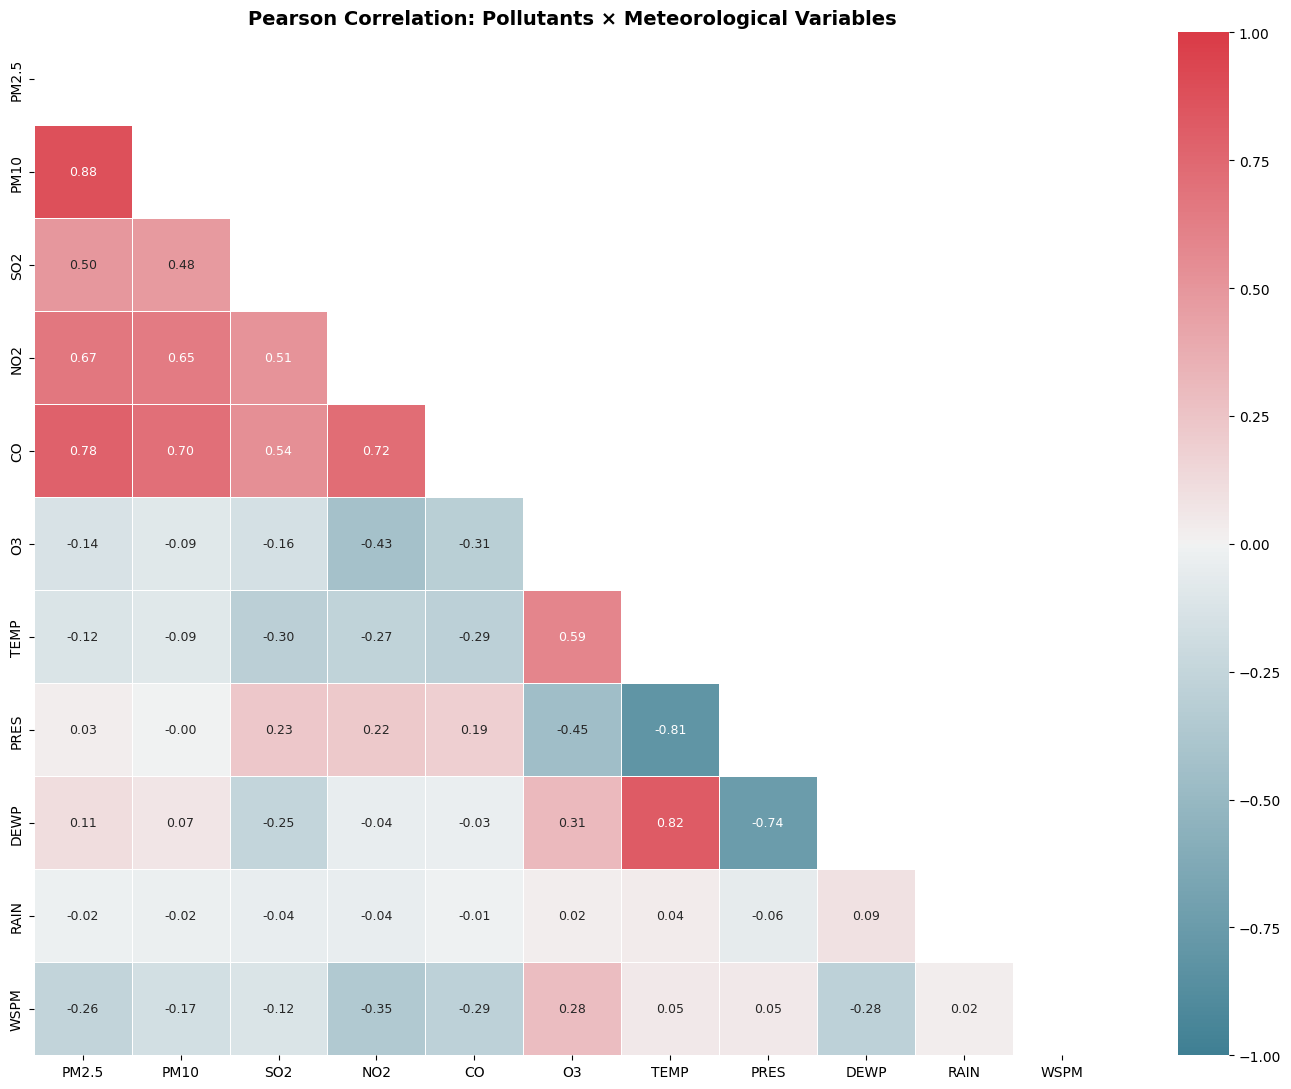

In [127]:
# ── 5a. Full correlation heatmap (pollutants + met) ──────────
all_vars = POLL_COLS + MET_COLS
corr_all = full_df[all_vars].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_all, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_all, mask=mask, cmap=cmap, vmin=-1, vmax=1,
            annot=True, fmt=".2f", linewidths=0.5,
            annot_kws={"size":9}, ax=ax)
ax.set_title("Pearson Correlation: Pollutants × Meteorological Variables",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_pollutant_met_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

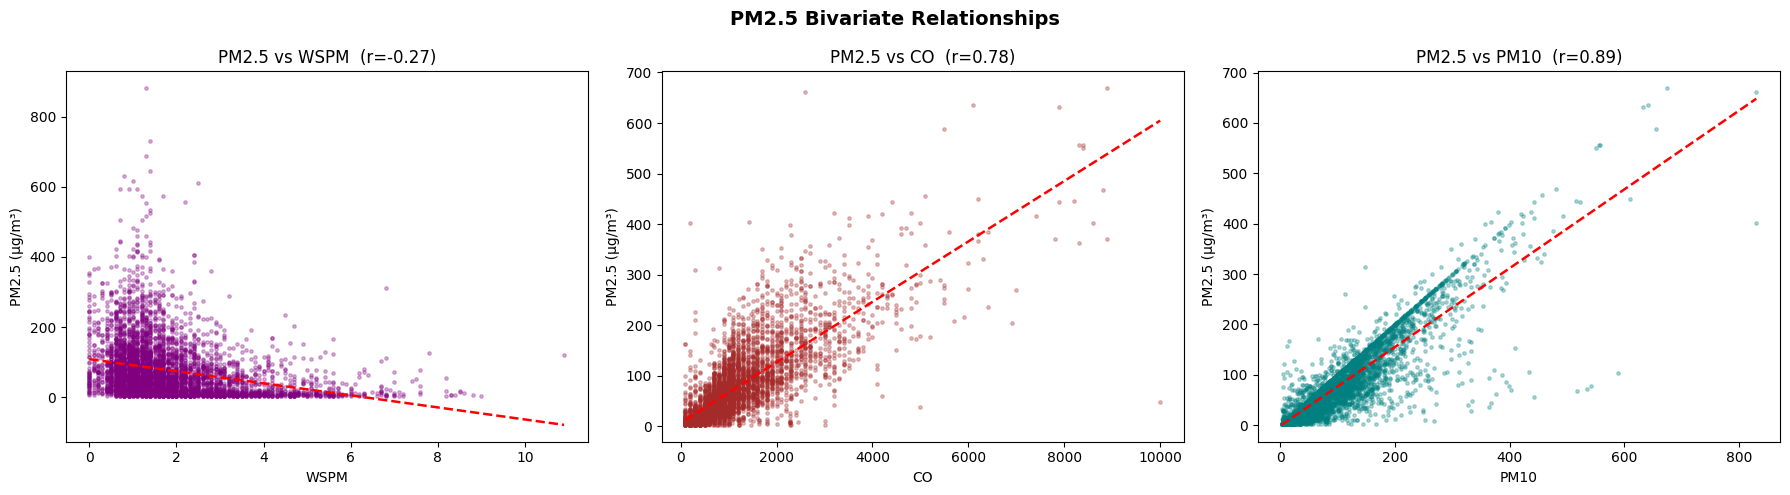


📌 INTERPRETATION:
  • WSPM: negative correlation — higher wind speed disperses particulates, lowering PM2.5.
  • CO: strong positive correlation — both emitted by incomplete combustion (vehicles, coal).
  • PM10: strong positive correlation — PM2.5 is a subset of PM10; they share emission sources.



In [128]:
# ─── PM2.5 vs Wind Speed, CO, PM10 ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PM2.5 Bivariate Relationships", fontsize=14, fontweight="bold")

pairs = [("WSPM","wind speed inhibits dispersion"), ("CO","co-emitted from combustion"), ("PM10","coarse vs fine particles")]
colors2 = ["purple","brown","teal"]

for ax, (xc, note), col in zip(axes, pairs, colors2):
    samp = full_df[[xc,"PM2.5"]].dropna().sample(min(5000,len(full_df)), random_state=42)
    ax.scatter(samp[xc], samp["PM2.5"], color=col, alpha=0.3, s=6)
    z = np.polyfit(samp[xc], samp["PM2.5"], 1)
    x_r = np.linspace(samp[xc].min(), samp[xc].max(), 200)
    ax.plot(x_r, np.poly1d(z)(x_r), "r--", linewidth=1.8)
    r = samp.corr().iloc[0,1]
    ax.set_xlabel(xc); ax.set_ylabel("PM2.5 (μg/m³)")
    ax.set_title(f"PM2.5 vs {xc}  (r={r:.2f})")

plt.tight_layout()
plt.savefig("fig_pm25_bivariate.png", dpi=150, bbox_inches="tight")
plt.show()
print("""
📌 INTERPRETATION:
  • WSPM: negative correlation — higher wind speed disperses particulates, lowering PM2.5.
  • CO: strong positive correlation — both emitted by incomplete combustion (vehicles, coal).
  • PM10: strong positive correlation — PM2.5 is a subset of PM10; they share emission sources.
""")

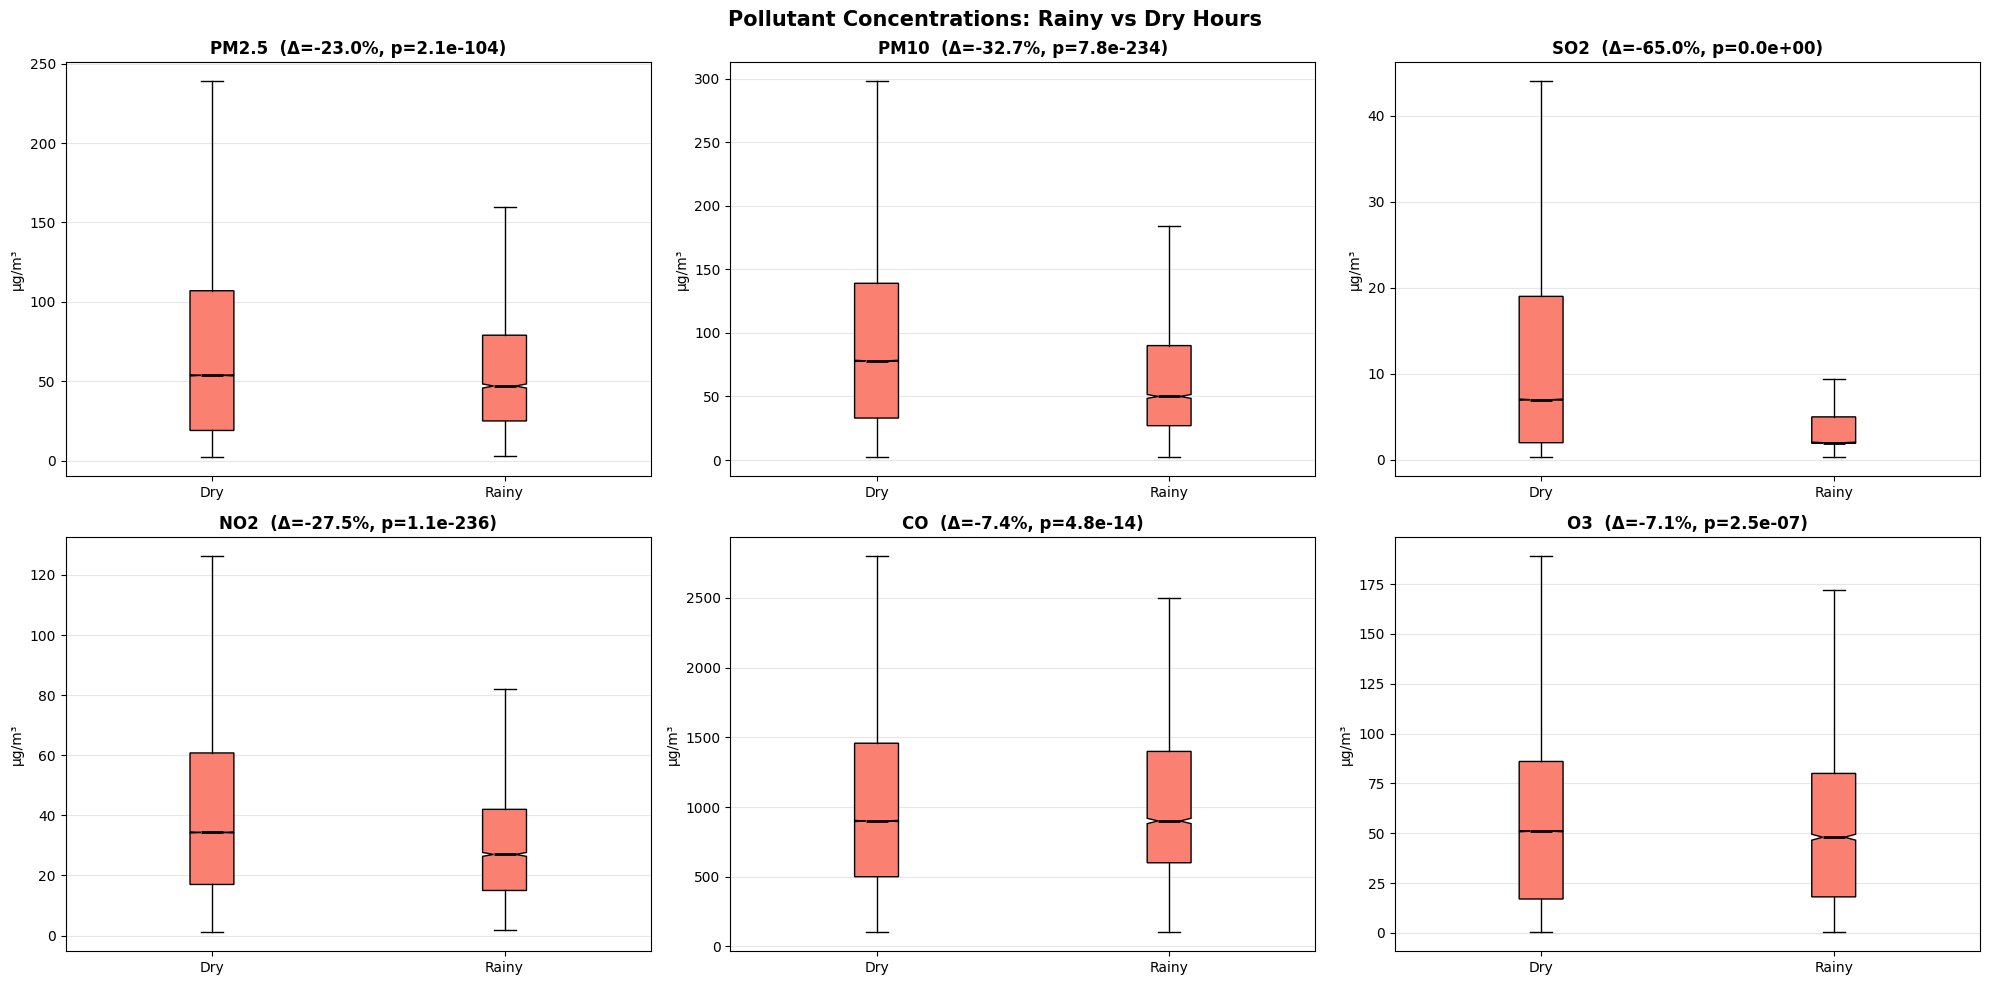

In [107]:
# ── 7a. Pollutants in Rainy vs Dry hours comparison ────────────────────────
from scipy import stats
from scipy.stats import pearsonr, spearmanr

POLL_COLS = ["PM2.5","PM10","SO2","NO2","CO","O3"]
POLL_COLS = [c for c in POLL_COLS if c in full_df.columns]

full_df["rain_flag"] = full_df["RAIN"].apply(lambda x: "Rainy (>0.1mm)" if x > 0.1 else "Dry (≤0.1mm)")

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("Pollutant Concentrations: Rainy vs Dry Hours", fontsize=15, fontweight="bold")

for ax, poll in zip(axes.flat, POLL_COLS):
    rainy = full_df[full_df["rain_flag"]=="Rainy (>0.1mm)"][poll].dropna()
    dry   = full_df[full_df["rain_flag"]=="Dry (≤0.1mm)"][poll].dropna()
    ax.boxplot([dry, rainy],
               labels=["Dry","Rainy"],
               notch=True, patch_artist=True,
               boxprops=dict(facecolor="salmon"),
               medianprops=dict(color="black", linewidth=2),
               showfliers=False)
    # t-test
    t_stat, p_val = stats.ttest_ind(rainy, dry, equal_var=False)
    pct_change = (rainy.mean() - dry.mean()) / dry.mean() * 100
    ax.set_title(f"{poll}  (Δ={pct_change:+.1f}%, p={p_val:.1e})", fontweight="bold")
    ax.set_ylabel("μg/m³"); ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("fig_rain_impact_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


In [108]:
full_df['region'].unique()

array(['Urban', 'Sub-urban'], dtype=object)

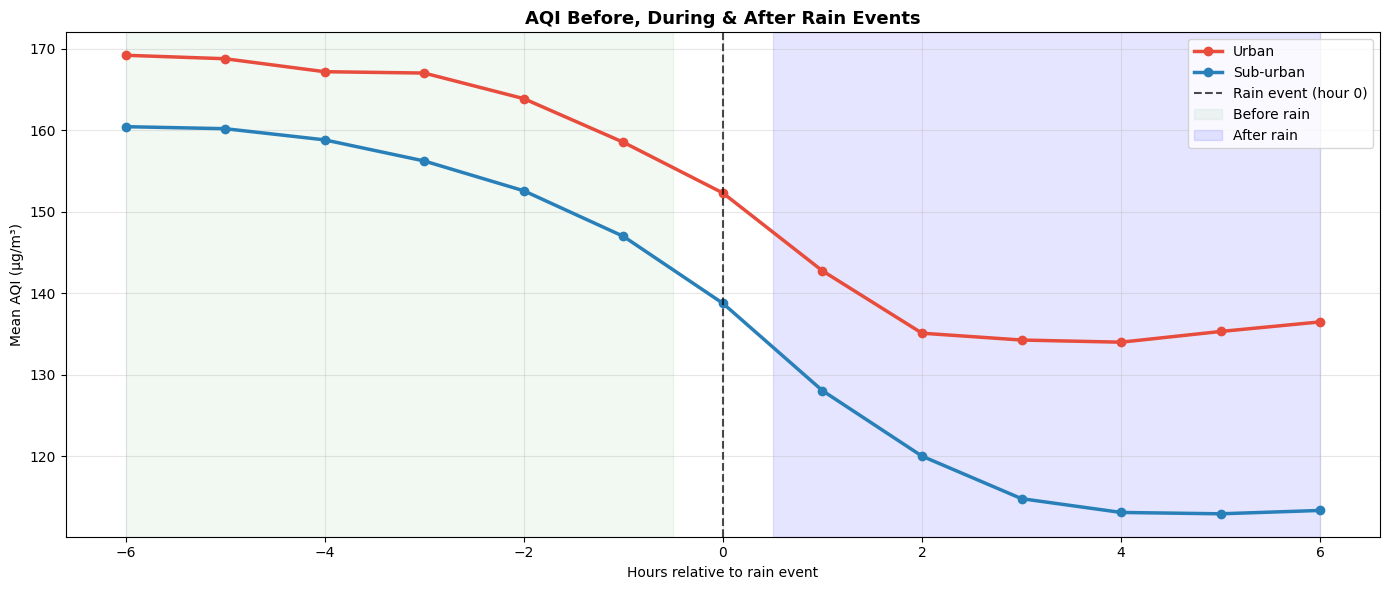


📌 INTERPRETATION:
  • PM2.5 drops significantly during and immediately after rain — wet deposition removes
    fine particles from the atmosphere.
  • Urban stations show a larger absolute drop (higher baseline) but a similar percentage reduction.
  • The drop is most rapid in the first 1–2 hours, then stabilises — this reflects the
    efficiency of rain washout for fine particles.
  • PM2.5 begins recovering within 3–4 hours after rain stops, as emissions continue.



In [129]:
# ── 7b. AQI before / during / after rain events ────────────
TYPE_COLORS   = {"Urban": "#e74c3c", "Sub-urban": "#2980b9"}
#TYPE_COLORS   = {"Dongsi": "#e74c3c", "Wanshouxigong": "#2980b9", "Dingling":"Green","Huairou":"Pink"}
# Define rain events: consecutive hours with RAIN > 0.1mm
df_sorted = full_df.sort_values(["station","datetime"]).copy()
df_sorted["rain_event"] = (df_sorted["RAIN"] > 0.1).astype(int)

# For each station, calculate lag/lead around rain hours
window = 6  # hours before and after
results = {"lag_h":[], "AQI_mean":[], "region":[]} ## should be based on "region":[]}

for stn in STATIONS:
    sub = df_sorted[df_sorted["station"]==stn].reset_index(drop=True)
    rain_idx = sub[sub["rain_event"]==1].index.tolist()
    for idx in rain_idx[:200]:  # sample 200 events per station
        for lag in range(-window, window+1):
            target_idx = idx + lag
            if 0 <= target_idx < len(sub):
                results["lag_h"].append(lag)
                results["AQI_mean"].append(sub.loc[target_idx,"AQI"])
                results["region"].append(sub.loc[target_idx,"region"]) # should be based on "region"

rain_impact_df = pd.DataFrame(results)     #
lag_avg = rain_impact_df.groupby(["lag_h","region"])["AQI_mean"].mean().reset_index() # should be based on "region"

fig, ax = plt.subplots(figsize=(14, 6))
for stype, color in TYPE_COLORS.items():
    sub = lag_avg[lag_avg["region"]==stype] ## should be based on "region"
    ax.plot(sub["lag_h"], sub["AQI_mean"], linewidth=2.5, marker="o",
            label=stype, color=color)
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.7, label="Rain event (hour 0)")
ax.axvspan(-window, -0.5, alpha=0.05, color="green", label="Before rain")
ax.axvspan(0.5, window,   alpha=0.1,  color="blue",  label="After rain")
ax.set_xlabel("Hours relative to rain event"); ax.set_ylabel("Mean AQI (μg/m³)")
ax.set_title("AQI Before, During & After Rain Events", fontsize=13, fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_pm25_before_after_rain.png", dpi=150, bbox_inches="tight")
plt.show()
print("""
📌 INTERPRETATION:
  • AQI drops significantly during and immediately after rain — wet deposition removes
    fine particles from the atmosphere.
  • Urban stations show a larger absolute drop (higher baseline) but a similar percentage reduction.
  • The drop is most rapid in the first 1–2 hours, then stabilises — this reflects the
    efficiency of rain washout for fine particles.
  • PM2.5 begins recovering within 3–4 hours after rain stops, as emissions continue.
""")